# # Bitcoin Price Direction Prediction Project

## Project Overview
This project aims to build a machine learning model to predict the direction of Bitcoin price movements (Up, Down, Sideways).
We will use **XGBoost** as the primary classifier and explore the integration of **Hidden Markov Models (HMM)** to capture market regimes.

## Key Steps:
1.  **Data Analysis**: Demonstrate non-stationarity of prices and failure of simple regression.
2.  **Target Generation**: Create "Oracle" labels using a zero-lag Centered Moving Average.
3.  **HMM Integration**: Model market states to use as features.
4.  **Classification**: Train XGBoost with iterative feature engineering and Grid Search.
5.  **Evaluation**: rigorous testing and visualization.


In [3]:
!conda install -c conda-forge hmmlearn -y

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\_PYTH\_ANACONDA\envs\XGB_fints_project

  added / updated specs:
    - hmmlearn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    expat-2.7.1                |       hac47afa_0         229 KB  conda-forge
    hmmlearn-0.3.3             |  py312hbb81ca0_1         200 KB  conda-forge
    python-3.12.7              |hce54a09_0_cpython        15.2 MB  conda-forge
    python_abi-3.12            |          8_cp312           7 KB  conda-forge
    ------------------------------------------------------------
                                           Total:        15.7 MB

The following NEW packages will be INSTALLED:

  hmmlearn           conda-forge/win-64::hmmlearn-0.3.3-py312hbb81ca0_1 
  libexpat           conda



==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.9.1

Please update conda by running

    $ conda update -n base -c defaults conda




In [128]:
!conda install -c conda-forge statsmodels -y

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.9.1

Please update conda by running

    $ conda update -n base -c defaults conda




In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_ta as ta
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
from hmmlearn.hmm import GaussianHMM
from scipy.ndimage import gaussian_filter1d
from statsmodels.tsa.stattools import adfuller
import warnings
import os

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-darkgrid')


In [140]:
def load_and_merge_data(
    fundings_path: str = "data/processed/fundings.parquet",
    klines_path: str = "data/processed/klines_15min_all.parquet",
    volumes_path: str = "data/processed/aggtrades_15min_all.parquet",
) -> pd.DataFrame:
    """Loads and merges funding, klines, and volume data."""
    print("Loading data...")
    fundings = pd.read_parquet(fundings_path)
    klines = pd.read_parquet(klines_path)
    volumes = pd.read_parquet(volumes_path)

    if "datetime" in volumes.columns: volumes = volumes.rename(columns={"datetime": "time"})
    if "calc_time" in fundings.columns: fundings = fundings.rename(columns={"calc_time": "time"})
    if "open_time" in klines.columns: klines = klines.rename(columns={"open_time": "time"})

    for col in ["time"]:
        volumes[col] = pd.to_datetime(volumes[col], utc=True)
        fundings[col] = pd.to_datetime(fundings[col], utc=True)
        klines[col] = pd.to_datetime(klines[col], utc=True)

    df = pd.merge(volumes, klines, on="time", how="inner")
    df = pd.merge(df, fundings, on="time", how="left")

    df = df.sort_values("time").reset_index(drop=True)
    if "funding_rate" in df.columns:
        df["funding_rate"] = df["funding_rate"].ffill()
    
    print(f"Data loaded successfully. Shape: {df.shape}")
    return df


In [141]:
# Load the data
df = load_and_merge_data()
print(df.head())


Loading data...
Data loaded successfully. Shape: (64320, 16)
                       time  total_vol   bid_vol  max_bid_vol  mod_bid_vol  \
0 2024-01-01 00:00:00+00:00   3616.424  1254.573       50.010        0.003   
1 2024-01-01 00:15:00+00:00   2322.028  1229.331       39.160        0.003   
2 2024-01-01 00:30:00+00:00   1684.217   879.438       20.174        0.003   
3 2024-01-01 00:45:00+00:00    835.244   408.159       15.407        0.003   
4 2024-01-01 01:00:00+00:00    850.274   482.286       50.858        0.003   

   avg_bid_vol   ask_vol  max_ask_vol  mod_ask_vol  avg_ask_vol     open  \
0     0.118133  2361.851       73.934        0.003     0.222397  42314.0   
1     0.145707  1092.697       30.074        0.003     0.129513  42532.4   
2     0.136326   804.779       14.077        0.003     0.124753  42458.4   
3     0.117625   427.085       18.973        0.003     0.123079  42474.5   
4     0.140077   367.988       16.992        0.003     0.106880  42503.5   

      high   

# ## 1. Data Analysis: Stationarity & Regression Failure
#
# ### 1.1 Stationarity Check
# Financial time series like Bitcoin prices are typically non-stationary (mean and variance change over time), making them unsuitable for direct prediction using many statistical models. Log-returns are usually stationary.
#
# We will use the **Augmented Dickey-Fuller (ADF)** test to statistically prove this.


--- ADF Test for Close Price ---
ADF Statistic: -0.9890
p-value: 0.7573
Critical Values:
	1%: -3.4310
	5%: -2.8618
	10%: -2.5669
Result: Close Price is NON-STATIONARY (Fail to reject H0)


--- ADF Test for Log Returns ---
ADF Statistic: -32.4312
p-value: 0.0000
Critical Values:
	1%: -3.4310
	5%: -2.8618
	10%: -2.5669
Result: Log Returns is STATIONARY (Reject H0)




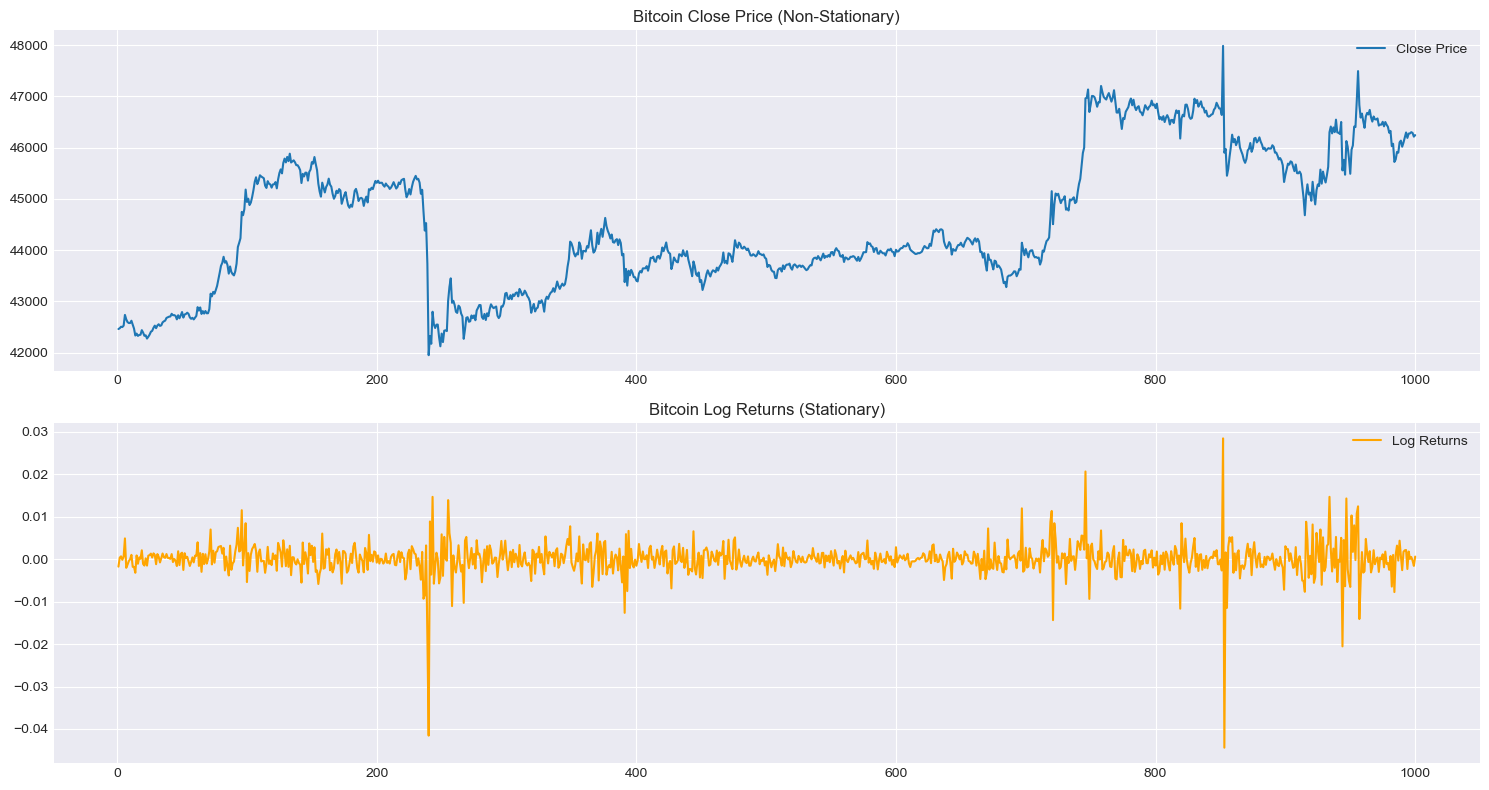

In [142]:
# Calculate Log Returns
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df = df.dropna()

def check_stationarity(series, name="Series"):
    result = adfuller(series)
    print(f"--- ADF Test for {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"\t{key}: {value:.4f}")
    
    if result[1] < 0.05:
        print(f"Result: {name} is STATIONARY (Reject H0)")
    else:
        print(f"Result: {name} is NON-STATIONARY (Fail to reject H0)")
    print("\n")

# Check Close Price
check_stationarity(df['close'].iloc[:10000], "Close Price")

# Check Log Returns
check_stationarity(df['log_return'].iloc[:10000], "Log Returns")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(df['close'].iloc[:1000], label='Close Price')
axes[0].set_title('Bitcoin Close Price (Non-Stationary)')
axes[0].legend()

axes[1].plot(df['log_return'].iloc[:1000], label='Log Returns', color='orange')
axes[1].set_title('Bitcoin Log Returns (Stationary)')
axes[1].legend()

plt.tight_layout()
plt.show()


# ### 1.2 Why Regression Fails
# We will now train a simple XGBoost Regressor to predict the *next bar's log-return* using a small subset of data.
# We expect the $R^2$ score to be close to zero (or negative), indicating that the model cannot predict the magnitude of price changes better than a simple mean baseline.


Regression MSE: 0.00000559
Regression R^2: -0.0425 (Expected to be near 0)


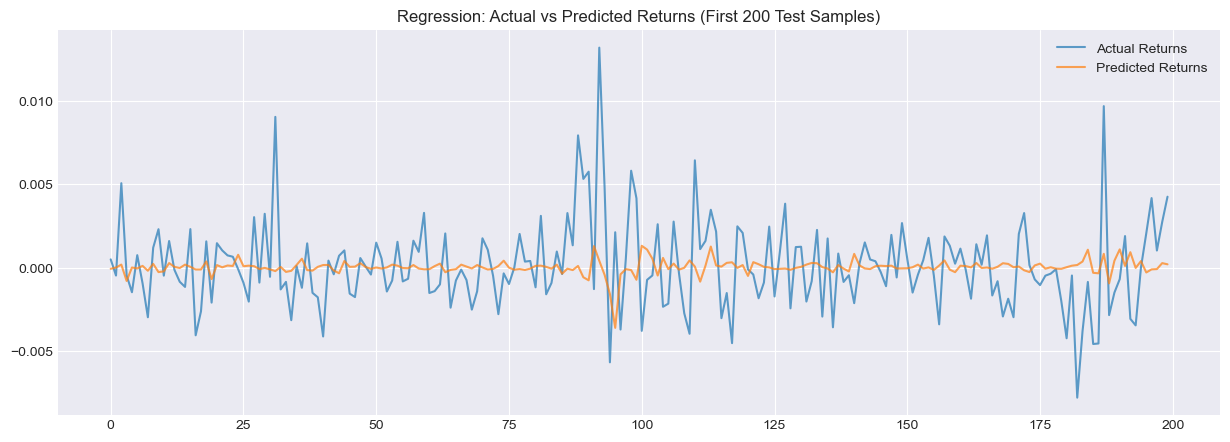

In [143]:
# Prepare data for regression demo (Subset)
subset_size = 5000
df_reg = df.iloc[:subset_size].copy()

# Features: Lagged returns
for i in range(1, 6):
    df_reg[f'lag_{i}'] = df_reg['log_return'].shift(i)

df_reg = df_reg.dropna()

X_reg = df_reg[[f'lag_{i}' for i in range(1, 6)]]
y_reg = df_reg['log_return'] # Predict next return

# Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, shuffle=False)

# Train Simple XGBoost Regressor
regressor = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
regressor.fit(X_train_reg, y_train_reg)

# Predict
y_pred_reg = regressor.predict(X_test_reg)

# Evaluate
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Regression MSE: {mse:.8f}")
print(f"Regression R^2: {r2:.4f} (Expected to be near 0)")

# Visualization
plt.figure(figsize=(15, 5))
plt.plot(y_test_reg.values[:200], label='Actual Returns', alpha=0.7)
plt.plot(y_pred_reg[:200], label='Predicted Returns', alpha=0.7)
plt.title('Regression: Actual vs Predicted Returns (First 200 Test Samples)')
plt.legend()
plt.show()


## 2. Target Generation: The "Oracle" Labeling

Since regression is difficult, we switch to **Classification** (Up/Down/Sideways).
To create high-quality labels, we use a **Centered Moving Average (Gaussian Smoothing)** on the *entire* dataset.

**Why?**

 This creates a smooth trend line that uses future data (zero lag). This is valid for *target generation* because we want to teach the model what *actually happened*. We must ensure we **never** use this smoothed line as a feature.

**Classes:**

 *   **2 (UP):** Slope > Threshold
 *   **0 (DOWN):** Slope < -Threshold
 *   **1 (SIDEWAYS):** |Slope| <= Threshold


In [144]:
def create_target_labels(df, sigma=1, threshold=0.0005):
    """
    Creates target labels using Gaussian smoothing (Centered MA).
    sigma: Controls smoothness (higher = smoother trend)
           Higher sigma => stronger smoothing, slower reaction to noise.
    threshold: Slope threshold for Up/Down classification
               If absolute slope is smaller than this value, we call it SIDEWAYS.
    """
    # Work on a copy to avoid modifying the original dataframe in-place
    df_target = df.copy()

    # 1. Apply Gaussian Filter (Centered Smoothing)
    # This uses the entire series (future and past) to smooth.
    # In practice this is a non-causal filter (uses future information),
    # so it is an "oracle" target, good for labeling but not for live trading.
    df_target['smoothed_close'] = gaussian_filter1d(
        df_target['close'],
        sigma=sigma
    )

    # 2. Calculate Slope (Derivative) of the smoothed line
    # We use log returns of the smoothed line to be scale-invariant:
    #    smooth_slope[t] ≈ log(S_t) - log(S_{t-1})
    # That means the slope is in relative units (percentage-ish),
    # not in raw price units.
    df_target['smooth_slope'] = np.diff(
        np.log(df_target['smoothed_close']),
        prepend=np.nan     # keep the same length as the original series
    )

    # 3. Define Classes
    # If slope is greater than +threshold  -> strong UP move (class 2).
    # If slope is smaller than -threshold  -> strong DOWN move (class 0).
    # Otherwise                             -> SIDEWAYS / neutral (class 1).
    conditions = [
        df_target['smooth_slope'] > threshold,
        df_target['smooth_slope'] < -threshold
    ]
    choices = [2, 0]  # 2=UP, 0=DOWN
    df_target['target'] = np.select(
        conditions,
        choices,
        default=1          # 1=SIDEWAYS
    )

    return df_target


# Hyperparameters for target generation.
# SIGMA controls how smooth the "oracle" line is.
# THRESHOLD controls how sensitive the labeling is to small slopes.
SIGMA = 4          # Smoothing factor (higher => smoother, fewer class flips)
THRESHOLD = 0.0004 # Slope threshold in log-return units

# Apply Target Generation
# Adjust sigma and threshold to get a balanced distribution of classes.
df_labeled = create_target_labels(df, sigma=SIGMA, threshold=THRESHOLD)

print("Class Distribution:")
print(df_labeled['target'].value_counts(normalize=True))

Class Distribution:
target
1    0.631369
2    0.195323
0    0.173308
Name: proportion, dtype: float64


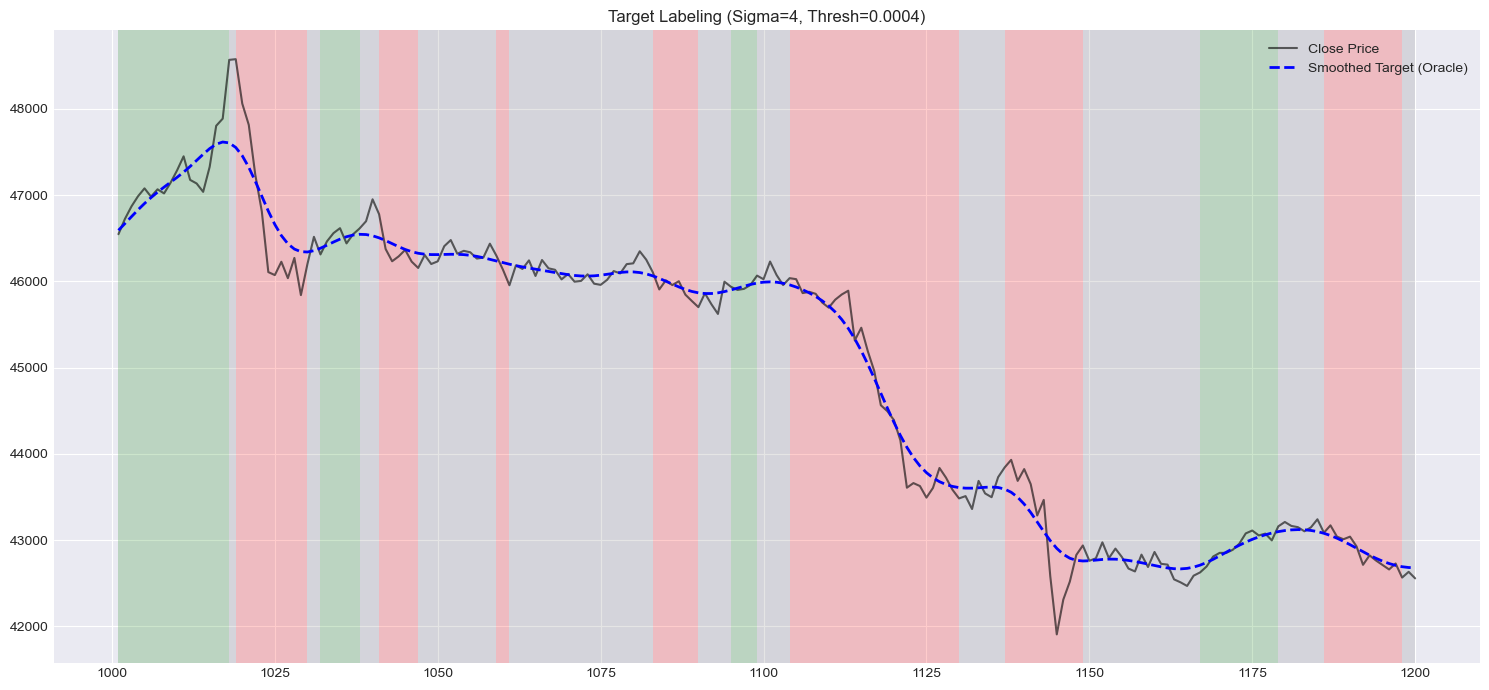

In [145]:


# Visualization of Labels
def plot_labels(df, start_idx, end_idx):
    """
    Plot a zoomed-in segment of the series with:
      - Raw close price
      - Smoothed 'oracle' price
      - Colored background according to the discrete target labels

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame that already contains 'close', 'smoothed_close' and 'target'.
    start_idx : int
        Integer position (iloc) where the visible window starts.
    end_idx : int
        Integer position (iloc) where the visible window ends (exclusive).
    """
    # Select a window by integer position to zoom into a local region
    subset = df.iloc[start_idx:end_idx]

    plt.figure(figsize=(15, 7))

    # Use the subset index as X-axis values.
    # If df has a DatetimeIndex, this will be time;
    # if it is a simple RangeIndex, these will be integer positions.
    x = subset.index

    # Plot Close Price (raw data)
    plt.plot(
        x,
        subset['close'],
        label='Close Price',
        color='black',
        alpha=0.6
    )

    # Plot Smoothed Target Line (oracle, uses future information)
    plt.plot(
        x,
        subset['smoothed_close'],
        label='Smoothed Target (Oracle)',
        color='blue',
        linestyle='--',
        linewidth=2
    )

    # Color background based on Target.
    # We fill vertical bands between x[i] and x[i+1] with a color
    # that depends on the target at time i:
    #   green = UP, red = DOWN, gray = SIDEWAYS.
    #
    # Important: we use x[i] / x[i+1] here (data coordinates),
    # not just i / i+1. This keeps the background aligned with the plot.
    for i in range(len(subset) - 1):
        x0 = x[i]
        x1 = x[i + 1]
        target = subset['target'].iloc[i]

        # Default color for SIDEWAYS
        color = 'gray'
        if target == 2:
            color = 'green'
        elif target == 0:
            color = 'red'

        # axvspan draws a vertical rectangle from x0 to x1 across the full y-range
        # (ymin=0, ymax=1 are in axis coordinates, so it always spans the full height).
        plt.axvspan(
            x0,
            x1,
            color=color,
            alpha=0.2,
            lw=0
        )

    plt.title(f'Target Labeling (Sigma={SIGMA}, Thresh={THRESHOLD})')
    plt.legend()
    plt.tight_layout()
    plt.show()


# Plot a zoomed-in section.
# Note: we pass df_labeled directly (without reset_index),
# so that indices used for plotting and for axvspan stay consistent.
plot_labels(df_labeled, 1000, 1200)


# ## 4. XGBoost Classifier Development

We will now build the main prediction model.

### 4.1 Feature Engineering

We will add a rich set of features:
*   **Volume:** Delta (Ask - Bid), Cumulative Delta, Moving Averages of Volume.
*   **Momentum:** RSI, MACD, EMA trends.
*   **Volatility:** Bollinger Bands (Width, %B).
*   **HMM Features:** The state probabilities we generated in the previous step.


## Brootforce search for optimal indicators combination ##

In [156]:
import pandas as pd
import pandas_ta as ta

from itertools import combinations

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

FEATURES_TO_REMOVE = ['target', 'time', 'smooth_slope', 'smoothed_close']


# ==============================
#   ИГРА С КОЛИЧЕСТВОМ ТОП‑ФИЧ
# ==============================

def rerun_with_top_k(df_labeled, base_groups, fi_df, k_list,
                     test_size=0.2, n_estimators=25, random_state=42):
    '''Эта функция rerun_with_top_k выполняет отбор признаков (Feature Selection).

Её задача — проверить, можно ли улучшить точность модели, если выкинуть "мусорные" признаки и оставить только самые важные (Топ-10, Топ-20 и т.д.).

Как она работает (пошагово):
Принимает на вход:

base_groups: набор групп индикаторов, который показал лучший результат на предыдущем этапе (например, ['momentum', 'trend']).
fi_df: таблица важности признаков (Feature Importance), полученная из лучшей модели.
k_list: список чисел (например, [10, 20, 30]), сколько лучших признаков оставлять.
Цикл по k (количеству признаков):

Берет названия топ-k самых важных признаков из fi_df.
Заново формирует датафрейм, применяя индикаторы из base_groups.
УДАЛЯЕТ все колонки, кроме этих топ-k признаков и служебных колонок (target, time).
Делает сдвиг shift(1) (чтобы предсказывать будущее по прошлому).
Обучает модель заново на этом урезанном наборе данных.
Записывает точность (accuracy).
Результат: Выводит таблицу, где видно, при каком количестве признаков точность максимальна. Часто бывает, что 20 лучших признаков работают лучше, чем все 100, так как убирается шум.'''

    out = []
    print(f"[rerun_with_top_k] base_groups={base_groups}, k_list={k_list}")

    # 1. Сначала готовим ПОЛНЫЙ датасет с нужными группами (ОДИН РАЗ)
    # Очищаем от старых индикаторов, оставляем только базу
    base_cols = ['time', 'open', 'high', 'low', 'close', 'total_vol', 'target']
    cols_to_keep = [c for c in base_cols if c in df_labeled.columns]
    df_full = df_labeled[cols_to_keep].copy()

    # Применяем группы индикаторов
    for g in base_groups:
        if g in GROUP_FUNCS:
            print(f"[rerun_with_top_k] apply group: {g}")
            df_full = GROUP_FUNCS[g](df_full)

    # 2. Теперь просто фильтруем колонки в цикле
    for k in k_list:
        # Берем имена топ-K признаков
        top_feats = fi_df.head(k)["Feature"].tolist()
        print(f"[rerun_with_top_k] start k={k}, top_feats_count={len(top_feats)}")

        # Копируем уже готовый датасет с индикаторами
        df = df_full.copy()

        # Оставляем только топ-K + служебные
        # Важно: FEATURES_TO_REMOVE должны быть защищены от удаления
        cols_to_retain = set(top_feats + FEATURES_TO_REMOVE)

        # Удаляем всё лишнее
        drop_cols = [c for c in df.columns if c not in cols_to_retain]
        df = df.drop(columns=drop_cols, errors="ignore")

        # Формируем список фичей для обучения (все что осталось, кроме служебных)
        features = [c for c in df.columns if c not in FEATURES_TO_REMOVE]

        # Сдвиг лага
        df[features] = df[features].shift(1)
        df = df.dropna()

        X = df[features]
        y = df["target"]

        # Обучение
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, shuffle=False
        )

        model = XGBClassifier(
            device='cuda',
            n_estimators=n_estimators,
            random_state=random_state,
            eval_metric='mlogloss',
            max_depth=4
        )
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))

        out.append({"k": k, "accuracy": acc})
        print(f"[rerun_with_top_k] done k={k}, acc={acc:.4f}")

    summary = pd.DataFrame(out).sort_values("accuracy", ascending=False)
    print("[rerun_with_top_k] finished, best:")
    print(summary.head(10))
    return summary


from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [157]:
# ==================================================================
#   ОБЁРТКИ НАД КАТЕГОРИЯМИ pandas-ta
# ==================================================================

def add_momentum_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Основные осцилляторы
    df.ta.rsi(length=14, append=True)
    df.ta.roc(length=12, append=True)
    df.ta.stoch(k=14, d=3, append=True)
    df.ta.stochrsi(length=14, append=True)
    df.ta.cci(length=14, append=True)       # Commodity Channel Index
    df.ta.willr(length=14, append=True)     # Williams %R
    df.ta.ao(append=True)                   # Awesome Oscillator
    df.ta.mom(length=10, append=True)       # Momentum
    df.ta.tsi(length_fast=13, length_slow=25, append=True) # True Strength Index
    df.ta.uo(append=True)                   # Ultimate Oscillator
    return df

def add_overlap_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Скользящие средние разных типов
    df.ta.ema(length=10, append=True)
    df.ta.ema(length=20, append=True)
    df.ta.ema(length=50, append=True)
    df.ta.ema(length=100, append=True)
    df.ta.sma(length=200, append=True)
    df.ta.hma(length=9, append=True)        # Hull Moving Average
    df.ta.tema(length=9, append=True)       # Triple EMA

    # Трендовые наложения
    df.ta.psar(append=True)                 # Parabolic SAR
    df.ta.supertrend(length=7, multiplier=3, append=True) # Supertrend

    # VWAP (требует объем)
    vol_col = 'volume' if 'volume' in df.columns else 'total_vol'
    if vol_col in df.columns:
        df.ta.vwap(high=df['high'], low=df['low'], close=df['close'], volume=df[vol_col], append=True)
    return df

def add_trend_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.ta.macd(fast=12, slow=26, append=True)
    df.ta.adx(length=14, append=True)
    df.ta.aroon(length=14, append=True)
    df.ta.vortex(length=14, append=True)    # Vortex Indicator
    df.ta.dpo(length=20, centered=False, append=True)       # Detrended Price Oscillator !!! by default centered=True => data leakage
    df.ta.trix(length=30, append=True)      # TRIX
    df.ta.cksp(append=True)                 # Chande Kroll Stop
    return df

def add_volatility_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.ta.atr(length=14, append=True)
    df.ta.natr(length=14, append=True)      # Normalized ATR
    df.ta.ui(length=14, append=True)        # Ulcer Index

    # Bollinger Bands (берем %B и ширину)
    bbands = df.ta.bbands(length=20, append=False)
    if bbands is not None and not bbands.empty:
        # Ищем колонки, начинающиеся с BBP (Percentage) и BBB (Bandwidth)
        bbp_cols = [c for c in bbands.columns if c.startswith('BBP')]
        bbb_cols = [c for c in bbands.columns if c.startswith('BBB')]

        if bbp_cols:
            df[bbp_cols[0]] = bbands[bbp_cols[0]]
        if bbb_cols:
            df[bbb_cols[0]] = bbands[bbb_cols[0]]

    # Keltner Channels (безопасное добавление)
    kc = df.ta.kc(append=False)
    if kc is not None and not kc.empty:
        # Пытаемся найти колонку KCP (Percentage)
        kcp_cols = [c for c in kc.columns if c.startswith('KCP')]
        if kcp_cols:
            df[kcp_cols[0]] = kc[kcp_cols[0]]

    # Donchian Channels (безопасное добавление)
    dc = df.ta.donchian(append=False)
    if dc is not None and not dc.empty:
        # Пытаемся найти колонку DCP (Percentage)
        dcp_cols = [c for c in dc.columns if c.startswith('DCP')]
        if dcp_cols:
            df[dcp_cols[0]] = dc[dcp_cols[0]]

    return df


def add_volume_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    vol_col = 'volume' if 'volume' in df.columns else 'total_vol'
    if vol_col in df.columns:
        df.ta.obv(close=df['close'], volume=df[vol_col], append=True)
        df.ta.mfi(high=df['high'], low=df['low'], close=df['close'], volume=df[vol_col], length=14, append=True)

        # ИСПРАВЛЕНО: метод называется .ad(), а не .adl()
        df.ta.ad(high=df['high'], low=df['low'], close=df['close'], volume=df[vol_col], append=True)

        df.ta.cmf(high=df['high'], low=df['low'], close=df['close'], volume=df[vol_col], append=True) # Chaikin Money Flow
        df.ta.eom(high=df['high'], low=df['low'], close=df['close'], volume=df[vol_col], append=True) # Ease of Movement
        df.ta.nvi(close=df['close'], volume=df[vol_col], append=True) # Negative Volume Index
        df.ta.pvi(close=df['close'], volume=df[vol_col], append=True) # Positive Volume Index
    return df


def add_statistics_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.ta.zscore(length=30, append=True)
    df.ta.entropy(length=30, append=True)
    df.ta.kurtosis(length=30, append=True)
    df.ta.skew(length=30, append=True)
    df.ta.variance(length=30, append=True)
    df.ta.mad(length=30, append=True) # Mean Absolute Deviation
    return df

def add_candle_category(df: pd.DataFrame) -> pd.DataFrame:
    """
    Безопасно добавляет расширенный набор свечных паттернов.
    """
    df = df.copy()

    # Расширенный список паттернов
    patterns_to_add = [
        'cdl_doji', 'cdl_hammer', 'cdl_engulfing',
        'cdl_morningstar', 'cdl_eveningstar',
        'cdl_shootingstar', 'cdl_hangingman',
        'cdl_marubozu', 'cdl_3whitesoldiers', 'cdl_3blackcrows',
        'cdl_inside', 'cdl_spinningtop'
    ]

    print("  -> Applying extended candle patterns...")
    for pattern_name in patterns_to_add:
        if hasattr(df.ta, pattern_name):
            getattr(df.ta, pattern_name)(append=True)
        else:
            # Тихо пропускаем или можно раскомментировать print для отладки
            # print(f"  -> WARNING: Candle pattern '{pattern_name}' not found.")
            pass

    return df


# ==============================
#   КОНФИГ: КАРТА ГРУПП
# ==============================

GROUP_FUNCS = {
    "momentum": add_momentum_category,
    "overlap": add_overlap_category,
    "trend": add_trend_category,
    "volatility": add_volatility_category,
    "volume": add_volume_category,
    "statistics": add_statistics_category,
    "candle": add_candle_category,
}


In [158]:
# ==================================================================
#   ОПТИМИЗИРОВАННЫЙ ПАЙПЛАЙН (СЧИТАЕМ 1 РАЗ -> ПЕРЕБИРАЕМ БЫСТРО)
# ==================================================================

def prepare_all_features(df_labeled: pd.DataFrame):
    """
    1. Приводит индекс к DatetimeIndex.
    2. Считает ВСЕ группы индикаторов сразу.
    3. Удаляет колонки, состоящие полностью из NaN.
    4. Возвращает полный датафрейм и карту {группа: [список_колонок]}.
    """
    print("[prepare_all_features] Pre-calculating ALL indicators...")
    df_all = df_labeled.copy()

    # 1. Исправляем индекс сразу (критично для VWAP)
    if 'time' in df_all.columns and not isinstance(df_all.index, pd.DatetimeIndex):
        df_all['time'] = pd.to_datetime(df_all['time'])
        df_all.set_index('time', inplace=True)

    # Запоминаем базовые колонки (чтобы случайно не удалить)
    base_cols = set(df_all.columns)
    group_features_map = {}

    # 2. Считаем все группы
    for g_name, g_func in GROUP_FUNCS.items():
        print(f"  -> Processing group: {g_name}")
        cols_before = set(df_all.columns)

        try:
            df_all = g_func(df_all)
        except Exception as e:
            print(f"    !!! CRITICAL ERROR in group '{g_name}': {e}")
            continue

        cols_after = set(df_all.columns)
        new_cols = list(cols_after - cols_before)
        group_features_map[g_name] = new_cols
        print(f"    -> Added {len(new_cols)} features.")

    # 3. Удаляем "битые" индикаторы (полностью NaN)
    nan_cols = df_all.columns[df_all.isna().all()].tolist()
    if nan_cols:
        print(f"[WARNING] Dropping {len(nan_cols)} columns that are 100% NaN: {nan_cols}")
        df_all.drop(columns=nan_cols, inplace=True)
        # Чистим карту групп
        for g in group_features_map:
            group_features_map[g] = [c for c in group_features_map[g] if c not in nan_cols]

    print(f"[prepare_all_features] Done. Total columns: {df_all.shape[1]}")
    return df_all, group_features_map


def run_fast_experiment(df_all, group_features_map, active_groups,
                        test_size=0.2, n_estimators=25, random_state=42):
    """
    Быстрый эксперимент: просто берет готовые колонки из df_all.
    """
    # 1. Собираем список нужных колонок индикаторов
    selected_indicator_cols = []
    for g in active_groups:
        selected_indicator_cols.extend(group_features_map.get(g, []))

    # 2. Добавляем базовые фичи (которые не в списке на удаление)
    #    Обычно это open, high, low, close, volume...
    all_cols = list(df_all.columns)
    # Оставляем те, которые (выбраны нами) ИЛИ (не являются индикаторами других групп И не в черном списке)
    # Проще: берем (базовые - remove) + (выбранные индикаторы)

    # Определяем базовые колонки (те, что были до индикаторов, примерно)
    # Но проще сделать так: берем всё, выкидываем индикаторы "чужих" групп

    # Все известные индикаторные колонки всех групп
    all_indicator_cols = set()
    for cols in group_features_map.values():
        all_indicator_cols.update(cols)

    # Колонки, которые не являются индикаторами (базовые цены)
    base_features = [c for c in all_cols if c not in all_indicator_cols and c not in FEATURES_TO_REMOVE]

    # Итоговый список фичей для этого эксперимента
    final_features = base_features + selected_indicator_cols

    # 3. Формируем датасет (копия среза - это быстро)
    # Добавляем target, если его нет в списке
    cols_to_take = list(set(final_features + ['target']))
    df_exp = df_all[cols_to_take].copy()

    # 4. Сдвиг фичей (Shift)
    # Сдвигаем всё, кроме таргета
    feat_cols = [c for c in df_exp.columns if c != 'target']
    df_exp[feat_cols] = df_exp[feat_cols].shift(1)

    # 5. Dropna
    rows_before = len(df_exp)
    df_exp.dropna(inplace=True)
    rows_after = len(df_exp)

    if df_exp.empty:
        return {'groups': active_groups, 'accuracy': 0, 'report': f'Empty after dropna (was {rows_before})',
                'n_features': 0}

    # 6. Обучение
    X = df_exp[feat_cols]
    y = df_exp['target'].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )

    if len(X_train) == 0 or len(X_test) == 0:
        return {'groups': active_groups, 'accuracy': 0, 'report': 'Train/Test empty', 'n_features': 0}

    model = XGBClassifier(
        device='cuda',
        n_estimators=n_estimators,
        random_state=random_state,
        eval_metric='mlogloss',
        max_depth=2
    )
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))

    # Важность признаков (опционально, можно отключить для скорости)
    fi_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    return {
        'groups': active_groups,
        'accuracy': acc,
        'n_features': len(feat_cols),
        'feature_importance': fi_df
    }


def iterate_group_combos_fast(df_labeled, max_group_size=4):
    # 1. Считаем всё один раз
    df_all, group_features_map = prepare_all_features(df_labeled)

    group_names = list(group_features_map.keys())
    combo_list = []
    for r in range(1, max_group_size + 1):
        for combo in combinations(group_names, r):
            combo_list.append(list(combo))

    total_runs = len(combo_list)
    print(f"\n[iterate_group_combos_fast] Starting {total_runs} experiments...")

    results = []
    for idx, groups in enumerate(combo_list, start=1):
        res = run_fast_experiment(df_all, group_features_map, groups)

        if res['accuracy'] > 0:
            print(f"Run {idx}/{total_runs} | {groups} | Acc: {res['accuracy']:.4f} | Feats: {res['n_features']}")
        else:
            print(f"Run {idx}/{total_runs} | {groups} | SKIPPED: {res.get('report')}")

        results.append(res)

    summary = pd.DataFrame([
        {
            "groups": "+".join(r["groups"]),
            "accuracy": r["accuracy"],
            "n_features": r.get("n_features", 0)
        }
        for r in results
    ]).sort_values("accuracy", ascending=False)

    return summary, results


# ЗАПУСК
summary, results = iterate_group_combos_fast(df_labeled, max_group_size=6)


[prepare_all_features] Pre-calculating ALL indicators...
  -> Processing group: momentum
    -> Added 13 features.
  -> Processing group: overlap
    -> Added 16 features.
  -> Processing group: trend
    -> Added 16 features.
  -> Processing group: volatility
    -> Added 5 features.
  -> Processing group: volume
    -> Added 7 features.
  -> Processing group: statistics
    -> Added 6 features.
  -> Processing group: candle
  -> Applying extended candle patterns...
    -> Added 0 features.
[prepare_all_features] Done. Total columns: 82

[iterate_group_combos_fast] Starting 126 experiments...
Run 1/126 | ['momentum'] | Acc: 0.7772 | Feats: 29
Run 2/126 | ['overlap'] | SKIPPED: Empty after dropna (was 64319)
Run 3/126 | ['trend'] | Acc: 0.7761 | Feats: 32
Run 4/126 | ['volatility'] | Acc: 0.7739 | Feats: 21
Run 5/126 | ['volume'] | Acc: 0.7659 | Feats: 23
Run 6/126 | ['statistics'] | Acc: 0.7767 | Feats: 22
Run 7/126 | ['candle'] | Acc: 0.7546 | Feats: 16
Run 8/126 | ['momentum', 'over

In [159]:

# 2) Лучший результат
best_res = max(results, key=lambda r: r["accuracy"])
fi = best_res["feature_importance"]
base_groups = best_res["groups"]

# 3) Играть количеством топ‑фич
topk_summary = rerun_with_top_k(
    df_labeled,
    base_groups=base_groups,
    fi_df=fi,
    k_list=[10, 20, 30, 40, 60, 80])



[rerun_with_top_k] base_groups=['momentum', 'trend', 'volatility', 'volume'], k_list=[10, 20, 30, 40, 60, 80]
[rerun_with_top_k] apply group: momentum
[rerun_with_top_k] apply group: trend
[rerun_with_top_k] apply group: volatility
[rerun_with_top_k] apply group: volume
[rerun_with_top_k] start k=10, top_feats_count=10
[rerun_with_top_k] done k=10, acc=0.7801
[rerun_with_top_k] start k=20, top_feats_count=20
[rerun_with_top_k] done k=20, acc=0.7811
[rerun_with_top_k] start k=30, top_feats_count=30
[rerun_with_top_k] done k=30, acc=0.7758
[rerun_with_top_k] start k=40, top_feats_count=40
[rerun_with_top_k] done k=40, acc=0.7709
[rerun_with_top_k] start k=60, top_feats_count=57
[rerun_with_top_k] done k=60, acc=0.7725
[rerun_with_top_k] start k=80, top_feats_count=57
[rerun_with_top_k] done k=80, acc=0.7725
[rerun_with_top_k] finished, best:
    k  accuracy
1  20  0.781131
0  10  0.780137
2  30  0.775842
4  60  0.772480
5  80  0.772480
3  40  0.770924


In [160]:
# ============================
# 1. Evaluate model on Test Set
# ============================

# Predicted class labels for the test set.
# Each element is in {0, 1, 2} corresponding to ['DOWN', 'SIDEWAYS', 'UP'].
y_pred = best_model.predict(X_test_scaled)

# Predicted class probabilities for the test set.
# Shape: (n_samples_test, 3). Each row sums to 1.0.
y_pred_proba = best_model.predict_proba(X_test_scaled)

print("\nClassification Report:")
# classification_report shows precision, recall, f1-score and support per class.
# target_names are simply human-readable names for classes 0,1,2.
print(classification_report(
    y_test,
    y_pred,
    target_names=['DOWN', 'SIDEWAYS', 'UP']
    #     target_names=['DOWN',  'UP']

))


Classification Report:
              precision    recall  f1-score   support

        DOWN       0.27      0.06      0.09      1505
    SIDEWAYS       0.71      0.95      0.81      6755
          UP       0.21      0.05      0.09      1374

    accuracy                           0.68      9634
   macro avg       0.40      0.35      0.33      9634
weighted avg       0.57      0.68      0.60      9634



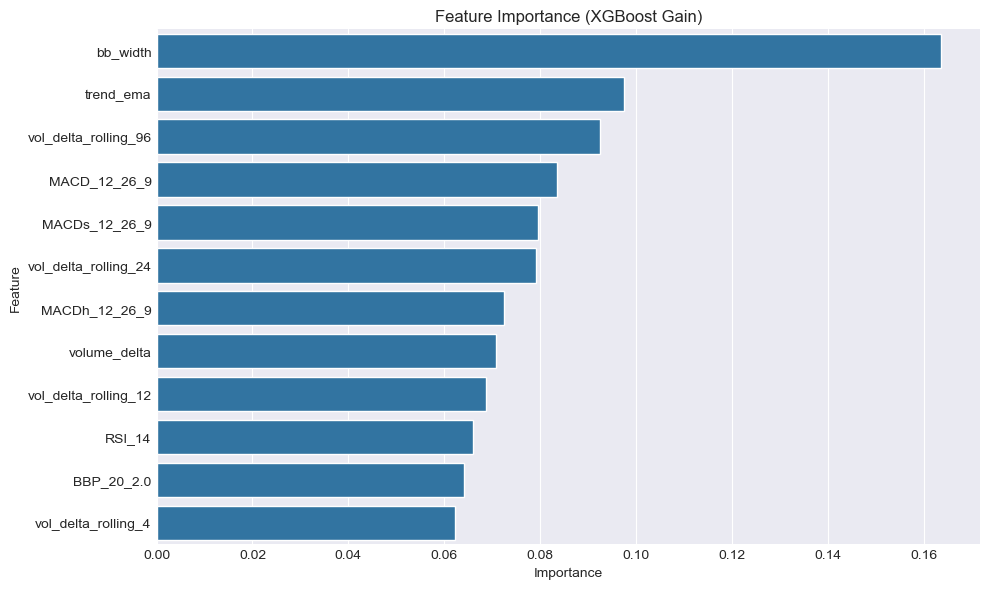

In [161]:

# ============================
# 3. Feature Importance
# ============================

# XGBoost provides feature_importances_ as the gain-based importance
# for each input feature used by the model.
importance = best_model.feature_importances_

# Build a DataFrame to sort and visualize feature importances.
feat_imp = (
    pd.DataFrame({'Feature': feature_cols, 'Importance': importance})
    .sort_values('Importance', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_imp,
    orient='h'
)
plt.title('Feature Importance (XGBoost Gain)')
plt.tight_layout()
plt.show()

In [162]:
# ============================
# 4. Attach predictions back to the full DataFrame
#    so that plotting is simple and index-safe.
# ============================

# Create empty columns for true and predicted labels in the full df.
# We will fill only the test segment.
df_full['y_true'] = np.nan
df_full['y_pred'] = np.nan

# y_test already has the correct index for the test segment (last part of df_full),
# because X_train / X_val / X_test were created from df_full WITHOUT shuffling.
test_index = y_test.index

# Write true and predicted labels into df_full aligned by index.
df_full.loc[test_index, 'y_true'] = y_test
df_full.loc[test_index, 'y_pred'] = y_pred

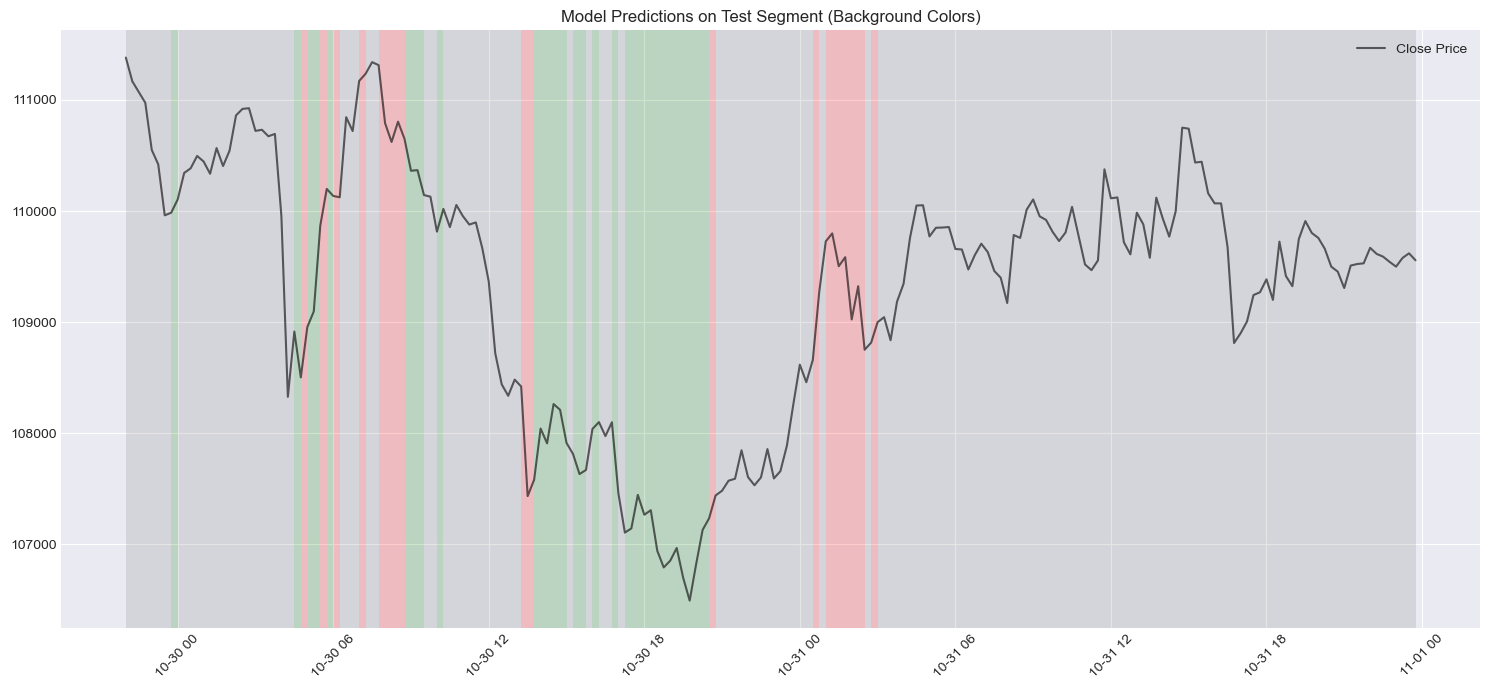

In [163]:
# ============================
# 5. Final Prediction Visualization
# ============================
def plot_predictions(df, y_test, y_pred, X_train, X_val, window_size=200):
    """
    Plot model predictions on the test segment of a time series as
    colored background behind the price.

    This function:
      1. Does NOT modify the original dataframe `df` (works on a copy).
      2. Automatically finds the test segment boundaries based on
         the lengths of X_train, X_val, X_test.
      3. Uses the 'time' column (if present) as the X-axis (dates),
         otherwise uses the existing index.
      4. Colors each bar interval according to the predicted class:
           0 = DOWN  (red)
           1 = SIDEWAYS (gray)
           2 = UP (green)

    Parameters
    ----------
    df : pandas.DataFrame
        Full dataframe that contains at least:
          - 'close' : price series
          - 'time'  : datetime column (optional but recommended).
        This function will NOT modify `df` in-place.

    y_test : pandas.Series or np.ndarray
        True labels for the test set. Length must match X_test.

    y_pred : np.ndarray or list-like
        Predicted class labels for the test set, aligned with y_test.

    X_train : pandas.DataFrame or np.ndarray
        Training features. Only the length is used to locate the test segment.

    X_val : pandas.DataFrame or np.ndarray
        Validation features. Only the length is used to locate the test segment.

    window_size : int, optional (default=200)
        Number of test bars to display in the plot starting from the
        beginning of the test segment.
    """
    # ------------------------------------------------------------------
    # 0. Work on a copy so that the original df is never changed.
    # ------------------------------------------------------------------
    df_plot = df.copy()

    # ------------------------------------------------------------------
    # 1. Prepare time index for plotting
    # ------------------------------------------------------------------
    # If there is a 'time' column, use it as a DatetimeIndex for the copy.
    # This allows the X-axis to show actual timestamps.
    if 'time' in df_plot.columns:
        # Ensure 'time' is datetime type
        if not isinstance(df_plot['time'].dtype, pd.DatetimeTZDtype) \
           and not np.issubdtype(df_plot['time'].dtype, np.datetime64):
            df_plot['time'] = pd.to_datetime(df_plot['time'])

        df_plot = df_plot.set_index('time')
        df_plot = df_plot.sort_index()   # make sure rows are in chronological order

    # At this point, df_plot.index is either:
    #   - DatetimeIndex (if 'time' existed), or
    #   - whatever index df had originally (RangeIndex, etc.).

    # ------------------------------------------------------------------
    # 2. Locate the test segment in df_plot by position
    # ------------------------------------------------------------------
    n_total = len(df_plot)
    n_train = len(X_train)
    n_val   = len(X_val)
    n_test  = len(y_test)

    # Sanity check: n_train + n_val + n_test should not exceed n_total.
    if n_train + n_val + n_test > n_total:
        raise ValueError(
            f"Lengths inconsistent: "
            f"n_train({n_train}) + n_val({n_val}) + n_test({n_test}) > n_total({n_total})."
        )

    # Assume that train, val, test are consecutive chunks at the END of df_plot
    # after all preprocessing (rolling, shift, dropna, etc.).
    # Then the test segment corresponds to the last n_test rows of df_plot.
    test_start_pos = n_total - n_test        # integer position where test starts
    test_end_pos   = n_total                 # integer position where test ends (exclusive)

    # ------------------------------------------------------------------
    # 3. Build a small helper DataFrame only for the test segment
    # ------------------------------------------------------------------
    # We create a view of df_plot restricted to the test range and
    # attach y_test and y_pred to it, without touching the original df.
    test_slice = df_plot.iloc[test_start_pos:test_end_pos].copy()

    # Ensure y_test is an array-like aligned by order.
    y_test_arr = np.asarray(y_test)
    y_pred_arr = np.asarray(y_pred)

    if len(test_slice) != len(y_test_arr):
        raise ValueError(
            f"Test slice length ({len(test_slice)}) != len(y_test) ({len(y_test_arr)}). "
            f"Check how you build X_train/X_val/X_test."
        )

    test_slice['y_true'] = y_test_arr
    test_slice['y_pred'] = y_pred_arr

    # ------------------------------------------------------------------
    # 4. Choose the window inside the test slice to visualize
    # ------------------------------------------------------------------
    # We start from the beginning of the test slice and take `window_size` bars.
    # plot_start = 0
    # plot_end   = min(window_size, len(test_slice))
    n_test_rows = len(test_slice)

    plot_start = n_test_rows - window_size
    plot_end   = n_test_rows

    subset = test_slice.iloc[plot_start:plot_end]

    if subset['y_pred'].isna().all():
        print("No predictions available in the selected window.")
        return

    # ------------------------------------------------------------------
    # 5. Plot: price line + background colored by predictions
    # ------------------------------------------------------------------
    plt.figure(figsize=(15, 7))

    # X-axis values: index of subset (dates if DatetimeIndex is used).
    x = subset.index

    # Plot the close price.
    plt.plot(
        x,
        subset['close'],
        color='black',
        alpha=0.6,
        label='Close Price'
    )

    # Class -> color mapping
    colors = {0: 'red', 1: 'gray', 2: 'green'}

    # Fill each interval [x[i], x[i+1]) with the color of predicted class at i.
    # Using x[i]/x[i+1] (data coordinates) ensures perfect alignment with the price.
    for i in range(len(subset) - 1):
        x0 = x[i]
        x1 = x[i + 1]
        pred = subset['y_pred'].iloc[i]

        if np.isnan(pred):
            continue

        plt.axvspan(
            x0,
            x1,
            color=colors.get(int(pred), 'gray'),
            alpha=0.2,
            lw=0
        )

    plt.title('Model Predictions on Test Segment (Background Colors)')
    plt.legend()
    plt.xticks(rotation=45)   # rotate datetime labels for readability
    plt.tight_layout()
    plt.show()
plot_predictions(df_full, y_test, y_pred, X_train, X_val, window_size=200)

In [164]:
def evaluate_model_performance(model, X_test, y_test):
  """
  Оценивает производительность модели и выводит отчет о классификации.

  Аргументы:
      model: Обученная модель для оценки.
      X_test: Массив признаков для тестового набора данных.
      y_test: Истинные метки для тестового набора данных.
  """
  # Получение прогнозов для тестового набора
  y_pred = model.predict(X_test)

  # Вывод отчета о классификации
  print("\nОтчет о классификации:")
  print(classification_report(
      y_test,
      y_pred,
      target_names=['DOWN', 'SIDEWAYS', 'UP']
  ))

# Пример использования:
evaluate_model_performance(best_model, X_test_scaled, y_test)


Отчет о классификации:
              precision    recall  f1-score   support

        DOWN       0.27      0.06      0.09      1505
    SIDEWAYS       0.71      0.95      0.81      6755
          UP       0.21      0.05      0.09      1374

    accuracy                           0.68      9634
   macro avg       0.40      0.35      0.33      9634
weighted avg       0.57      0.68      0.60      9634



# OLD

In [136]:
df.ta.bbands(length=20, std=2, append=True)
df.columns

Index(['time', 'total_vol', 'bid_vol', 'max_bid_vol', 'mod_bid_vol',
       'avg_bid_vol', 'ask_vol', 'max_ask_vol', 'mod_ask_vol', 'avg_ask_vol',
       'open', 'high', 'low', 'close', 'count', 'funding_rate', 'log_return',
       'BBL_20_2.0', 'BBM_20_2.0', 'BBU_20_2.0', 'BBB_20_2.0', 'BBP_20_2.0'],
      dtype='object')

In [19]:
df_labeled.columns

Index(['time', 'total_vol', 'bid_vol', 'max_bid_vol', 'mod_bid_vol',
       'avg_bid_vol', 'ask_vol', 'max_ask_vol', 'mod_ask_vol', 'avg_ask_vol',
       'open', 'high', 'low', 'close', 'count', 'funding_rate', 'log_return',
       'smoothed_close', 'smooth_slope', 'target'],
      dtype='object')

In [30]:
df_labeled = df_labeled[['time', 'total_vol', 'bid_vol', 'max_bid_vol', 'mod_bid_vol',
       'avg_bid_vol', 'ask_vol', 'max_ask_vol', 'mod_ask_vol', 'avg_ask_vol',
       'open', 'high', 'low', 'close', 'count', 'funding_rate', 'log_return','target']]

In [57]:
def add_features(df):
    df = df.copy()
    
    # --- Volume Features ---
    df["volume_delta"] = df["ask_vol"] - df["bid_vol"]
    for window in [4, 12, 24, 96]:
        df[f"vol_delta_rolling_{window}"] = df["volume_delta"].rolling(window).sum()
    
    # --- Momentum Features ---
    df.ta.rsi(length=14, append=True)
    df.ta.macd(fast=12, slow=26, signal=9, append=True)
    df['ema_12'] = ta.ema(df['close'], length=12)
    df['ema_26'] = ta.ema(df['close'], length=26)
    df['trend_ema'] = np.where(df['ema_12'] > df['ema_26'], 1, -1)
    
    # --- Volatility Features ---
    df.ta.bbands(length=20, std=2, append=True)
    df['bb_width'] = (df['BBU_20_2.0'] - df['BBL_20_2.0']) / df['BBM_20_2.0']
    
    return df

# Apply Feature Engineering
df_full = add_features(df_labeled)

# Define Feature Columns (Exclude Target and Future Data)
feature_cols = [
    'volume_delta', 'vol_delta_rolling_4', 'vol_delta_rolling_12', 'vol_delta_rolling_24', 'vol_delta_rolling_96',
    'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'trend_ema',
    'bb_width', 'BBP_20_2.0'
]

# Shift features by 1 to prevent look-ahead bias (predicting NEXT bar using CURRENT features)
df_full[feature_cols] = df_full[feature_cols].shift(1)
df_full = df_full.dropna()

print(f"Features: {len(feature_cols)}")
print(feature_cols)


Features: 12
['volume_delta', 'vol_delta_rolling_4', 'vol_delta_rolling_12', 'vol_delta_rolling_24', 'vol_delta_rolling_96', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'trend_ema', 'bb_width', 'BBP_20_2.0']


In [98]:
# ### 4.2 Grid Search & Training
# We will use `RandomizedSearchCV` (a more efficient version of Grid Search) to find optimal hyperparameters for XGBoost.
# We will perform 200 iterations.


In [58]:
# Prepare X and y
X = df_full[feature_cols]
y = df_full['target']

# Split Data (Time Series Split)
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_val = X.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]

X_test = X.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]

# Scale Features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define Hyperparameter Grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5]
}

# Initialize XGBoost
xgb = XGBClassifier(
    objective='multi:softprob', 
    num_class=3, 
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    tree_method='hist', # Faster training
    max_depth=3,
    n_estimators=20
)

# Randomized Search (200 iterations)
print("Starting Grid Search (200 iterations)...")
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_weighted',
    cv=TimeSeriesSplit(n_splits=3),
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print("Best Parameters:", random_search.best_params_)
best_model = random_search.best_estimator_


Starting Grid Search (200 iterations)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [59]:
# ## 5. Evaluation & Visualization
#
# We evaluate the best model on the Test set and visualize the results.


In [138]:
# ============================
# 1. Evaluate model on Test Set
# ============================

# Predicted class labels for the test set.
# Each element is in {0, 1, 2} corresponding to ['DOWN', 'SIDEWAYS', 'UP'].
y_pred = best_model.predict(X_test_scaled)

# Predicted class probabilities for the test set.
# Shape: (n_samples_test, 3). Each row sums to 1.0.
y_pred_proba = best_model.predict_proba(X_test_scaled)

print("\nClassification Report:")
# classification_report shows precision, recall, f1-score and support per class.
# target_names are simply human-readable names for classes 0,1,2.
print(classification_report(
    y_test,
    y_pred,
    target_names=['DOWN', 'SIDEWAYS', 'UP']
    #     target_names=['DOWN',  'UP']

))


Classification Report:
              precision    recall  f1-score   support

        DOWN       0.27      0.06      0.09      1505
    SIDEWAYS       0.71      0.95      0.81      6755
          UP       0.21      0.05      0.09      1374

    accuracy                           0.68      9634
   macro avg       0.40      0.35      0.33      9634
weighted avg       0.57      0.68      0.60      9634



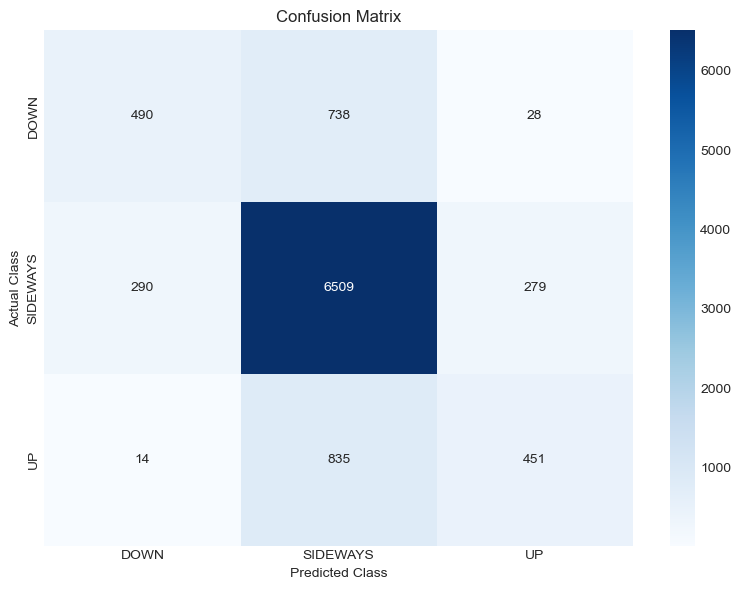

In [35]:

# ============================
# 2. Confusion Matrix
# ============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,                # show counts inside the cells
    fmt='d',                   # integer format
    cmap='Blues',
    xticklabels=['DOWN', 'SIDEWAYS', 'UP'],  # predicted labels
    yticklabels=['DOWN', 'SIDEWAYS', 'UP']   # true labels
)
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

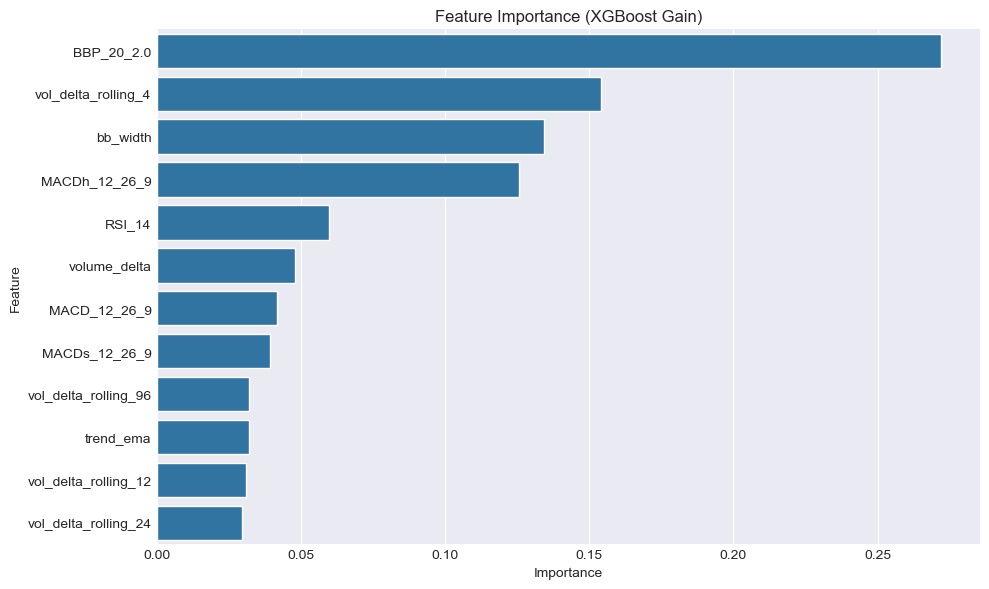

In [36]:

# ============================
# 3. Feature Importance
# ============================

# XGBoost provides feature_importances_ as the gain-based importance
# for each input feature used by the model.
importance = best_model.feature_importances_

# Build a DataFrame to sort and visualize feature importances.
feat_imp = (
    pd.DataFrame({'Feature': feature_cols, 'Importance': importance})
    .sort_values('Importance', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_imp,
    orient='h'
)
plt.title('Feature Importance (XGBoost Gain)')
plt.tight_layout()
plt.show()

In [37]:

# ============================
# 4. Attach predictions back to the full DataFrame
#    so that plotting is simple and index-safe.
# ============================

# Create empty columns for true and predicted labels in the full df.
# We will fill only the test segment.
df_full['y_true'] = np.nan
df_full['y_pred'] = np.nan

# y_test already has the correct index for the test segment (last part of df_full),
# because X_train / X_val / X_test were created from df_full WITHOUT shuffling.
test_index = y_test.index

# Write true and predicted labels into df_full aligned by index.
df_full.loc[test_index, 'y_true'] = y_test
df_full.loc[test_index, 'y_pred'] = y_pred

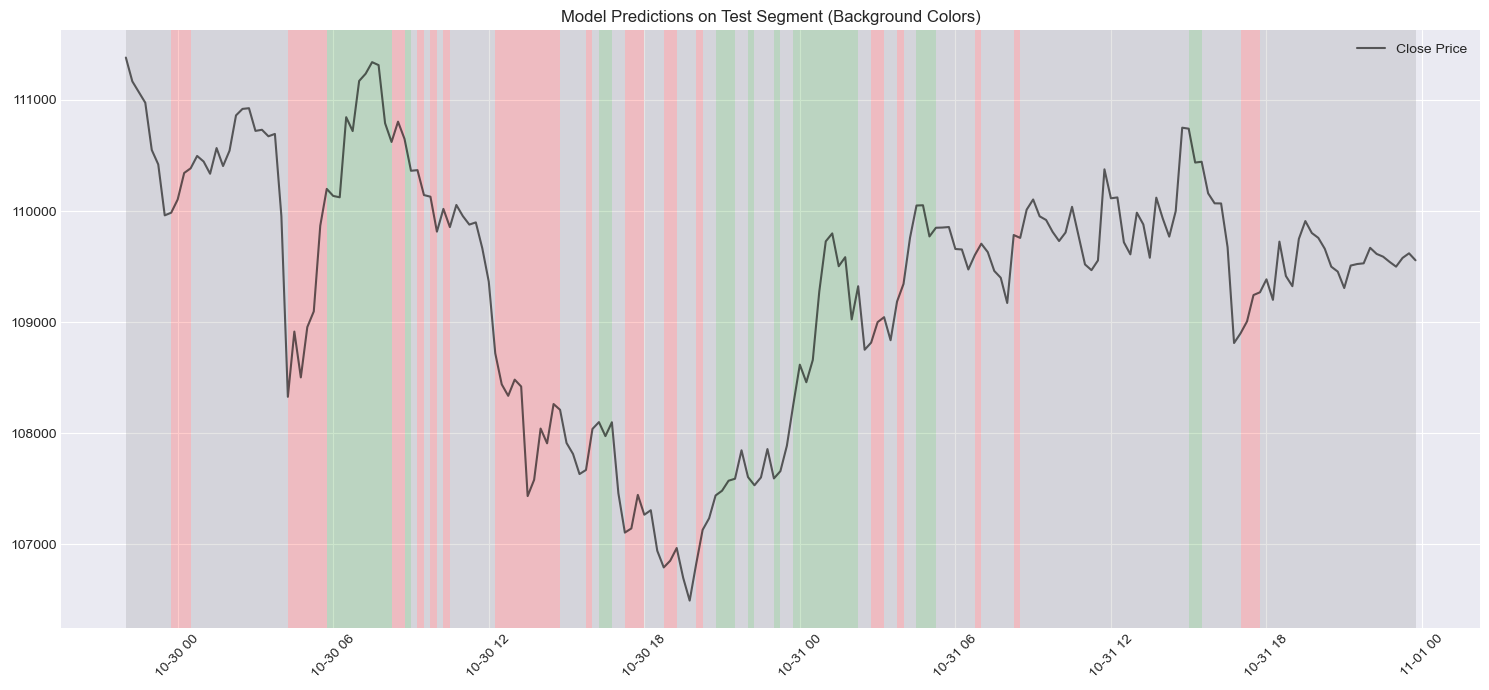

In [38]:

# ============================
# 5. Final Prediction Visualization
# ============================
def plot_predictions(df, y_test, y_pred, X_train, X_val, window_size=200):
    """
    Plot model predictions on the test segment of a time series as
    colored background behind the price.

    This function:
      1. Does NOT modify the original dataframe `df` (works on a copy).
      2. Automatically finds the test segment boundaries based on
         the lengths of X_train, X_val, X_test.
      3. Uses the 'time' column (if present) as the X-axis (dates),
         otherwise uses the existing index.
      4. Colors each bar interval according to the predicted class:
           0 = DOWN  (red)
           1 = SIDEWAYS (gray)
           2 = UP (green)

    Parameters
    ----------
    df : pandas.DataFrame
        Full dataframe that contains at least:
          - 'close' : price series
          - 'time'  : datetime column (optional but recommended).
        This function will NOT modify `df` in-place.

    y_test : pandas.Series or np.ndarray
        True labels for the test set. Length must match X_test.

    y_pred : np.ndarray or list-like
        Predicted class labels for the test set, aligned with y_test.

    X_train : pandas.DataFrame or np.ndarray
        Training features. Only the length is used to locate the test segment.

    X_val : pandas.DataFrame or np.ndarray
        Validation features. Only the length is used to locate the test segment.

    window_size : int, optional (default=200)
        Number of test bars to display in the plot starting from the
        beginning of the test segment.
    """
    # ------------------------------------------------------------------
    # 0. Work on a copy so that the original df is never changed.
    # ------------------------------------------------------------------
    df_plot = df.copy()

    # ------------------------------------------------------------------
    # 1. Prepare time index for plotting
    # ------------------------------------------------------------------
    # If there is a 'time' column, use it as a DatetimeIndex for the copy.
    # This allows the X-axis to show actual timestamps.
    if 'time' in df_plot.columns:
        # Ensure 'time' is datetime type
        if not isinstance(df_plot['time'].dtype, pd.DatetimeTZDtype) \
           and not np.issubdtype(df_plot['time'].dtype, np.datetime64):
            df_plot['time'] = pd.to_datetime(df_plot['time'])

        df_plot = df_plot.set_index('time')
        df_plot = df_plot.sort_index()   # make sure rows are in chronological order

    # At this point, df_plot.index is either:
    #   - DatetimeIndex (if 'time' existed), or
    #   - whatever index df had originally (RangeIndex, etc.).

    # ------------------------------------------------------------------
    # 2. Locate the test segment in df_plot by position
    # ------------------------------------------------------------------
    n_total = len(df_plot)
    n_train = len(X_train)
    n_val   = len(X_val)
    n_test  = len(y_test)

    # Sanity check: n_train + n_val + n_test should not exceed n_total.
    if n_train + n_val + n_test > n_total:
        raise ValueError(
            f"Lengths inconsistent: "
            f"n_train({n_train}) + n_val({n_val}) + n_test({n_test}) > n_total({n_total})."
        )

    # Assume that train, val, test are consecutive chunks at the END of df_plot
    # after all preprocessing (rolling, shift, dropna, etc.).
    # Then the test segment corresponds to the last n_test rows of df_plot.
    test_start_pos = n_total - n_test        # integer position where test starts
    test_end_pos   = n_total                 # integer position where test ends (exclusive)

    # ------------------------------------------------------------------
    # 3. Build a small helper DataFrame only for the test segment
    # ------------------------------------------------------------------
    # We create a view of df_plot restricted to the test range and
    # attach y_test and y_pred to it, without touching the original df.
    test_slice = df_plot.iloc[test_start_pos:test_end_pos].copy()

    # Ensure y_test is an array-like aligned by order.
    y_test_arr = np.asarray(y_test)
    y_pred_arr = np.asarray(y_pred)

    if len(test_slice) != len(y_test_arr):
        raise ValueError(
            f"Test slice length ({len(test_slice)}) != len(y_test) ({len(y_test_arr)}). "
            f"Check how you build X_train/X_val/X_test."
        )

    test_slice['y_true'] = y_test_arr
    test_slice['y_pred'] = y_pred_arr

    # ------------------------------------------------------------------
    # 4. Choose the window inside the test slice to visualize
    # ------------------------------------------------------------------
    # We start from the beginning of the test slice and take `window_size` bars.
    # plot_start = 0
    # plot_end   = min(window_size, len(test_slice))
    n_test_rows = len(test_slice)

    plot_start = n_test_rows - window_size
    plot_end   = n_test_rows

    subset = test_slice.iloc[plot_start:plot_end]

    if subset['y_pred'].isna().all():
        print("No predictions available in the selected window.")
        return

    # ------------------------------------------------------------------
    # 5. Plot: price line + background colored by predictions
    # ------------------------------------------------------------------
    plt.figure(figsize=(15, 7))

    # X-axis values: index of subset (dates if DatetimeIndex is used).
    x = subset.index

    # Plot the close price.
    plt.plot(
        x,
        subset['close'],
        color='black',
        alpha=0.6,
        label='Close Price'
    )

    # Class -> color mapping
    colors = {0: 'red', 1: 'gray', 2: 'green'}

    # Fill each interval [x[i], x[i+1]) with the color of predicted class at i.
    # Using x[i]/x[i+1] (data coordinates) ensures perfect alignment with the price.
    for i in range(len(subset) - 1):
        x0 = x[i]
        x1 = x[i + 1]
        pred = subset['y_pred'].iloc[i]

        if np.isnan(pred):
            continue

        plt.axvspan(
            x0,
            x1,
            color=colors.get(int(pred), 'gray'),
            alpha=0.2,
            lw=0
        )

    plt.title('Model Predictions on Test Segment (Background Colors)')
    plt.legend()
    plt.xticks(rotation=45)   # rotate datetime labels for readability
    plt.tight_layout()
    plt.show()
plot_predictions(df_full, y_test, y_pred, X_train, X_val, window_size=200)

In [39]:
def evaluate_model_performance(model, X_test, y_test):
  """
  Оценивает производительность модели и выводит отчет о классификации.

  Аргументы:
      model: Обученная модель для оценки.
      X_test: Массив признаков для тестового набора данных.
      y_test: Истинные метки для тестового набора данных.
  """
  # Получение прогнозов для тестового набора
  y_pred = model.predict(X_test)

  # Вывод отчета о классификации
  print("\nОтчет о классификации:")
  print(classification_report(
      y_test,
      y_pred,
      target_names=['DOWN', 'SIDEWAYS', 'UP']
  ))

# Пример использования:
evaluate_model_performance(best_model, X_test_scaled, y_test)


Отчет о классификации:
              precision    recall  f1-score   support

        DOWN       0.62      0.39      0.48      1256
    SIDEWAYS       0.81      0.92      0.86      7078
          UP       0.59      0.35      0.44      1300

    accuracy                           0.77      9634
   macro avg       0.67      0.55      0.59      9634
weighted avg       0.75      0.77      0.75      9634



###_###########################################################################################################################################################################

## Brootforce search for optimal indicators combination ##

In [40]:
import pandas as pd
import pandas_ta as ta

from itertools import combinations

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

FEATURES_TO_REMOVE = ['target', 'time', 'smooth_slope', 'smoothed_close']


# ==============================
#   ИГРА С КОЛИЧЕСТВОМ ТОП‑ФИЧ
# ==============================

def rerun_with_top_k(df_labeled, base_groups, fi_df, k_list,
                     test_size=0.2, n_estimators=25, random_state=42):

    '''Эта функция rerun_with_top_k выполняет отбор признаков (Feature Selection).

Её задача — проверить, можно ли улучшить точность модели, если выкинуть "мусорные" признаки и оставить только самые важные (Топ-10, Топ-20 и т.д.).

Как она работает (пошагово):
Принимает на вход:

base_groups: набор групп индикаторов, который показал лучший результат на предыдущем этапе (например, ['momentum', 'trend']).
fi_df: таблица важности признаков (Feature Importance), полученная из лучшей модели.
k_list: список чисел (например, [10, 20, 30]), сколько лучших признаков оставлять.
Цикл по k (количеству признаков):

Берет названия топ-k самых важных признаков из fi_df.
Заново формирует датафрейм, применяя индикаторы из base_groups.
УДАЛЯЕТ все колонки, кроме этих топ-k признаков и служебных колонок (target, time).
Делает сдвиг shift(1) (чтобы предсказывать будущее по прошлому).
Обучает модель заново на этом урезанном наборе данных.
Записывает точность (accuracy).
Результат: Выводит таблицу, где видно, при каком количестве признаков точность максимальна. Часто бывает, что 20 лучших признаков работают лучше, чем все 100, так как убирается шум.'''

    out = []
    print(f"[rerun_with_top_k] base_groups={base_groups}, k_list={k_list}")

    # 1. Сначала готовим ПОЛНЫЙ датасет с нужными группами (ОДИН РАЗ)
    # Очищаем от старых индикаторов, оставляем только базу
    base_cols = ['time', 'open', 'high', 'low', 'close',  'total_vol', 'target']
    cols_to_keep = [c for c in base_cols if c in df_labeled.columns]
    df_full = df_labeled[cols_to_keep].copy()

    # Применяем группы индикаторов
    for g in base_groups:
        if g in GROUP_FUNCS:
            print(f"[rerun_with_top_k] apply group: {g}")
            df_full = GROUP_FUNCS[g](df_full)

    # 2. Теперь просто фильтруем колонки в цикле
    for k in k_list:
        # Берем имена топ-K признаков
        top_feats = fi_df.head(k)["Feature"].tolist()
        print(f"[rerun_with_top_k] start k={k}, top_feats_count={len(top_feats)}")

        # Копируем уже готовый датасет с индикаторами
        df = df_full.copy()

        # Оставляем только топ-K + служебные
        # Важно: FEATURES_TO_REMOVE должны быть защищены от удаления
        cols_to_retain = set(top_feats + FEATURES_TO_REMOVE)

        # Удаляем всё лишнее
        drop_cols = [c for c in df.columns if c not in cols_to_retain]
        df = df.drop(columns=drop_cols, errors="ignore")

        # Формируем список фичей для обучения (все что осталось, кроме служебных)
        features = [c for c in df.columns if c not in FEATURES_TO_REMOVE]

        # Сдвиг лага
        df[features] = df[features].shift(1)
        df = df.dropna()

        X = df[features]
        y = df["target"]

        # Обучение
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, shuffle=False
        )

        model = XGBClassifier(
            device='cuda',
            n_estimators=n_estimators,
            random_state=random_state,
            eval_metric='mlogloss',
            max_depth=4
        )
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))

        out.append({"k": k, "accuracy": acc})
        print(f"[rerun_with_top_k] done k={k}, acc={acc:.4f}")

    summary = pd.DataFrame(out).sort_values("accuracy", ascending=False)
    print("[rerun_with_top_k] finished, best:")
    print(summary.head(10))
    return summary

In [144]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [49]:

# ==================================================================
#   ОБЁРТКИ НАД КАТЕГОРИЯМИ pandas-ta
# ==================================================================

def add_momentum_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Основные осцилляторы
    df.ta.rsi(length=14, append=True)
    df.ta.roc(length=12, append=True)
    df.ta.stoch(k=14, d=3, append=True)
    df.ta.stochrsi(length=14, append=True)
    df.ta.cci(length=14, append=True)       # Commodity Channel Index
    df.ta.willr(length=14, append=True)     # Williams %R
    df.ta.ao(append=True)                   # Awesome Oscillator
    df.ta.mom(length=10, append=True)       # Momentum
    df.ta.tsi(length_fast=13, length_slow=25, append=True) # True Strength Index
    df.ta.uo(append=True)                   # Ultimate Oscillator
    return df

def add_overlap_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Скользящие средние разных типов
    df.ta.ema(length=10, append=True)
    df.ta.ema(length=20, append=True)
    df.ta.ema(length=50, append=True)
    df.ta.ema(length=100, append=True)
    df.ta.sma(length=200, append=True)
    df.ta.hma(length=9, append=True)        # Hull Moving Average
    df.ta.tema(length=9, append=True)       # Triple EMA

    # Трендовые наложения
    df.ta.psar(append=True)                 # Parabolic SAR
    df.ta.supertrend(length=7, multiplier=3, append=True) # Supertrend

    # VWAP (требует объем)
    vol_col = 'volume' if 'volume' in df.columns else 'total_vol'
    if vol_col in df.columns:
        df.ta.vwap(high=df['high'], low=df['low'], close=df['close'], volume=df[vol_col], append=True)
    return df

def add_trend_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.ta.macd(fast=12, slow=26, append=True)
    df.ta.adx(length=14, append=True)
    df.ta.aroon(length=14, append=True)
    df.ta.vortex(length=14, append=True)    # Vortex Indicator
    df.ta.dpo(length=20, centered=False, append=True)       # Detrended Price Oscillator !!! by default centered=True => data leakage
    df.ta.trix(length=30, append=True)      # TRIX
    df.ta.cksp(append=True)                 # Chande Kroll Stop
    return df

def add_volatility_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.ta.atr(length=14, append=True)
    df.ta.natr(length=14, append=True)      # Normalized ATR
    df.ta.ui(length=14, append=True)        # Ulcer Index

    # Bollinger Bands (берем %B и ширину)
    bbands = df.ta.bbands(length=20, append=False)
    if bbands is not None and not bbands.empty:
        # Ищем колонки, начинающиеся с BBP (Percentage) и BBB (Bandwidth)
        bbp_cols = [c for c in bbands.columns if c.startswith('BBP')]
        bbb_cols = [c for c in bbands.columns if c.startswith('BBB')]

        if bbp_cols:
            df[bbp_cols[0]] = bbands[bbp_cols[0]]
        if bbb_cols:
            df[bbb_cols[0]] = bbands[bbb_cols[0]]

    # Keltner Channels (безопасное добавление)
    kc = df.ta.kc(append=False)
    if kc is not None and not kc.empty:
        # Пытаемся найти колонку KCP (Percentage)
        kcp_cols = [c for c in kc.columns if c.startswith('KCP')]
        if kcp_cols:
            df[kcp_cols[0]] = kc[kcp_cols[0]]

    # Donchian Channels (безопасное добавление)
    dc = df.ta.donchian(append=False)
    if dc is not None and not dc.empty:
        # Пытаемся найти колонку DCP (Percentage)
        dcp_cols = [c for c in dc.columns if c.startswith('DCP')]
        if dcp_cols:
            df[dcp_cols[0]] = dc[dcp_cols[0]]

    return df


def add_volume_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    vol_col = 'volume' if 'volume' in df.columns else 'total_vol'
    if vol_col in df.columns:
        df.ta.obv(close=df['close'], volume=df[vol_col], append=True)
        df.ta.mfi(high=df['high'], low=df['low'], close=df['close'], volume=df[vol_col], length=14, append=True)

        # ИСПРАВЛЕНО: метод называется .ad(), а не .adl()
        df.ta.ad(high=df['high'], low=df['low'], close=df['close'], volume=df[vol_col], append=True)

        df.ta.cmf(high=df['high'], low=df['low'], close=df['close'], volume=df[vol_col], append=True) # Chaikin Money Flow
        df.ta.eom(high=df['high'], low=df['low'], close=df['close'], volume=df[vol_col], append=True) # Ease of Movement
        df.ta.nvi(close=df['close'], volume=df[vol_col], append=True) # Negative Volume Index
        df.ta.pvi(close=df['close'], volume=df[vol_col], append=True) # Positive Volume Index
    return df


def add_statistics_category(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.ta.zscore(length=30, append=True)
    df.ta.entropy(length=30, append=True)
    df.ta.kurtosis(length=30, append=True)
    df.ta.skew(length=30, append=True)
    df.ta.variance(length=30, append=True)
    df.ta.mad(length=30, append=True) # Mean Absolute Deviation
    return df

def add_candle_category(df: pd.DataFrame) -> pd.DataFrame:
    """
    Безопасно добавляет расширенный набор свечных паттернов.
    """
    df = df.copy()

    # Расширенный список паттернов
    patterns_to_add = [
        'cdl_doji', 'cdl_hammer', 'cdl_engulfing',
        'cdl_morningstar', 'cdl_eveningstar',
        'cdl_shootingstar', 'cdl_hangingman',
        'cdl_marubozu', 'cdl_3whitesoldiers', 'cdl_3blackcrows',
        'cdl_inside', 'cdl_spinningtop'
    ]

    print("  -> Applying extended candle patterns...")
    for pattern_name in patterns_to_add:
        if hasattr(df.ta, pattern_name):
            getattr(df.ta, pattern_name)(append=True)
        else:
            # Тихо пропускаем или можно раскомментировать print для отладки
            # print(f"  -> WARNING: Candle pattern '{pattern_name}' not found.")
            pass

    return df


# ==============================
#   КОНФИГ: КАРТА ГРУПП
# ==============================

GROUP_FUNCS = {
    "momentum": add_momentum_category,
    "overlap": add_overlap_category,
    "trend": add_trend_category,
    "volatility": add_volatility_category,
    "volume": add_volume_category,
    "statistics": add_statistics_category,
    "candle": add_candle_category,
}


In [50]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier



In [51]:
# ==================================================================
#   ОПТИМИЗИРОВАННЫЙ ПАЙПЛАЙН (СЧИТАЕМ 1 РАЗ -> ПЕРЕБИРАЕМ БЫСТРО)
# ==================================================================

def prepare_all_features(df_labeled: pd.DataFrame):
    """
    1. Приводит индекс к DatetimeIndex.
    2. Считает ВСЕ группы индикаторов сразу.
    3. Удаляет колонки, состоящие полностью из NaN.
    4. Возвращает полный датафрейм и карту {группа: [список_колонок]}.
    """
    print("[prepare_all_features] Pre-calculating ALL indicators...")
    df_all = df_labeled.copy()

    # 1. Исправляем индекс сразу (критично для VWAP)
    if 'time' in df_all.columns and not isinstance(df_all.index, pd.DatetimeIndex):
        df_all['time'] = pd.to_datetime(df_all['time'])
        df_all.set_index('time', inplace=True)

    # Запоминаем базовые колонки (чтобы случайно не удалить)
    base_cols = set(df_all.columns)
    group_features_map = {}

    # 2. Считаем все группы
    for g_name, g_func in GROUP_FUNCS.items():
        print(f"  -> Processing group: {g_name}")
        cols_before = set(df_all.columns)

        try:
            df_all = g_func(df_all)
        except Exception as e:
            print(f"    !!! CRITICAL ERROR in group '{g_name}': {e}")
            continue

        cols_after = set(df_all.columns)
        new_cols = list(cols_after - cols_before)
        group_features_map[g_name] = new_cols
        print(f"    -> Added {len(new_cols)} features.")

    # 3. Удаляем "битые" индикаторы (полностью NaN)
    nan_cols = df_all.columns[df_all.isna().all()].tolist()
    if nan_cols:
        print(f"[WARNING] Dropping {len(nan_cols)} columns that are 100% NaN: {nan_cols}")
        df_all.drop(columns=nan_cols, inplace=True)
        # Чистим карту групп
        for g in group_features_map:
            group_features_map[g] = [c for c in group_features_map[g] if c not in nan_cols]

    print(f"[prepare_all_features] Done. Total columns: {df_all.shape[1]}")
    return df_all, group_features_map


def run_fast_experiment(df_all, group_features_map, active_groups,
                        test_size=0.2, n_estimators=25, random_state=42):
    """
    Быстрый эксперимент: просто берет готовые колонки из df_all.
    """
    # 1. Собираем список нужных колонок индикаторов
    selected_indicator_cols = []
    for g in active_groups:
        selected_indicator_cols.extend(group_features_map.get(g, []))

    # 2. Добавляем базовые фичи (которые не в списке на удаление)
    #    Обычно это open, high, low, close, volume...
    all_cols = list(df_all.columns)
    # Оставляем те, которые (выбраны нами) ИЛИ (не являются индикаторами других групп И не в черном списке)
    # Проще: берем (базовые - remove) + (выбранные индикаторы)

    # Определяем базовые колонки (те, что были до индикаторов, примерно)
    # Но проще сделать так: берем всё, выкидываем индикаторы "чужих" групп

    # Все известные индикаторные колонки всех групп
    all_indicator_cols = set()
    for cols in group_features_map.values():
        all_indicator_cols.update(cols)

    # Колонки, которые не являются индикаторами (базовые цены)
    base_features = [c for c in all_cols if c not in all_indicator_cols and c not in FEATURES_TO_REMOVE]

    # Итоговый список фичей для этого эксперимента
    final_features = base_features + selected_indicator_cols

    # 3. Формируем датасет (копия среза - это быстро)
    # Добавляем target, если его нет в списке
    cols_to_take = list(set(final_features + ['target']))
    df_exp = df_all[cols_to_take].copy()

    # 4. Сдвиг фичей (Shift)
    # Сдвигаем всё, кроме таргета
    feat_cols = [c for c in df_exp.columns if c != 'target']
    df_exp[feat_cols] = df_exp[feat_cols].shift(1)

    # 5. Dropna
    rows_before = len(df_exp)
    df_exp.dropna(inplace=True)
    rows_after = len(df_exp)

    if df_exp.empty:
        return {'groups': active_groups, 'accuracy': 0, 'report': f'Empty after dropna (was {rows_before})', 'n_features': 0}

    # 6. Обучение
    X = df_exp[feat_cols]
    y = df_exp['target'].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )

    if len(X_train) == 0 or len(X_test) == 0:
         return {'groups': active_groups, 'accuracy': 0, 'report': 'Train/Test empty', 'n_features': 0}

    model = XGBClassifier(
        device='cuda',
        n_estimators=n_estimators,
        random_state=random_state,
        eval_metric='mlogloss',
        max_depth=4
    )
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))

    # Важность признаков (опционально, можно отключить для скорости)
    fi_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    return {
        'groups': active_groups,
        'accuracy': acc,
        'n_features': len(feat_cols),
        'feature_importance': fi_df
    }

def iterate_group_combos_fast(df_labeled, max_group_size=4):
    # 1. Считаем всё один раз
    df_all, group_features_map = prepare_all_features(df_labeled)

    group_names = list(group_features_map.keys())
    combo_list = []
    for r in range(1, max_group_size + 1):
        for combo in combinations(group_names, r):
            combo_list.append(list(combo))

    total_runs = len(combo_list)
    print(f"\n[iterate_group_combos_fast] Starting {total_runs} experiments...")

    results = []
    for idx, groups in enumerate(combo_list, start=1):
        res = run_fast_experiment(df_all, group_features_map, groups)

        if res['accuracy'] > 0:
            print(f"Run {idx}/{total_runs} | {groups} | Acc: {res['accuracy']:.4f} | Feats: {res['n_features']}")
        else:
            print(f"Run {idx}/{total_runs} | {groups} | SKIPPED: {res.get('report')}")

        results.append(res)

    summary = pd.DataFrame([
        {
            "groups": "+".join(r["groups"]),
            "accuracy": r["accuracy"],
            "n_features": r.get("n_features", 0)
        }
        for r in results
    ]).sort_values("accuracy", ascending=False)

    return summary, results

# ЗАПУСК
summary, results = iterate_group_combos_fast(df_labeled, max_group_size=6)


[prepare_all_features] Pre-calculating ALL indicators...
  -> Processing group: momentum
    -> Added 13 features.
  -> Processing group: overlap
    -> Added 16 features.
  -> Processing group: trend
    -> Added 16 features.
  -> Processing group: volatility
    -> Added 5 features.
  -> Processing group: volume
    -> Added 7 features.
  -> Processing group: statistics
    -> Added 6 features.
  -> Processing group: candle
  -> Applying extended candle patterns...
    -> Added 0 features.
[prepare_all_features] Done. Total columns: 80

[iterate_group_combos_fast] Starting 126 experiments...
Run 1/126 | ['momentum'] | Acc: 0.7743 | Feats: 29
Run 2/126 | ['overlap'] | SKIPPED: Empty after dropna (was 64319)
Run 3/126 | ['trend'] | Acc: 0.7688 | Feats: 32
Run 4/126 | ['volatility'] | Acc: 0.7620 | Feats: 21
Run 5/126 | ['volume'] | Acc: 0.7610 | Feats: 23
Run 6/126 | ['statistics'] | Acc: 0.7734 | Feats: 22
Run 7/126 | ['candle'] | Acc: 0.7494 | Feats: 16
Run 8/126 | ['momentum', 'over

In [165]:

# 2) Лучший результат
best_res = max(results, key=lambda r: r["accuracy"])
fi = best_res["feature_importance"]
base_groups = best_res["groups"]

# 3) Играть количеством топ‑фич
topk_summary = rerun_with_top_k(
    df_labeled,
    base_groups=base_groups,
    fi_df=fi,
    k_list=[10, 20, 30, 40, 60, 80])



[rerun_with_top_k] base_groups=['momentum', 'trend', 'volatility', 'volume'], k_list=[10, 20, 30, 40, 60, 80]
[rerun_with_top_k] apply group: momentum
[rerun_with_top_k] apply group: trend
[rerun_with_top_k] apply group: volatility
[rerun_with_top_k] apply group: volume
[rerun_with_top_k] start k=10, top_feats_count=10
[rerun_with_top_k] done k=10, acc=0.7801
[rerun_with_top_k] start k=20, top_feats_count=20
[rerun_with_top_k] done k=20, acc=0.7811
[rerun_with_top_k] start k=30, top_feats_count=30
[rerun_with_top_k] done k=30, acc=0.7758
[rerun_with_top_k] start k=40, top_feats_count=40
[rerun_with_top_k] done k=40, acc=0.7709
[rerun_with_top_k] start k=60, top_feats_count=57
[rerun_with_top_k] done k=60, acc=0.7725
[rerun_with_top_k] start k=80, top_feats_count=57
[rerun_with_top_k] done k=80, acc=0.7725
[rerun_with_top_k] finished, best:
    k  accuracy
1  20  0.781131
0  10  0.780137
2  30  0.775842
4  60  0.772480
5  80  0.772480
3  40  0.770924


In [166]:
import json
import joblib

# 1. Извлекаем имена лучших 40 фичей из вашего dataframe важности (fi)
# fi - это переменная из предыдущего шага (best_res["feature_importance"])
best_k = 40
top_features = fi.head(best_k)["Feature"].tolist()

print(f"Selected {len(top_features)} features.")
print(top_features[:10], "...") # Показать первые 10

# 2. Подготовка финального датасета
# Берем df_all (который мы посчитали в iterate_group_combos_fast)
# Если переменная df_all потерялась, раскомментируйте строку ниже:
df_all, _ = prepare_all_features(df_labeled)

final_df = df_all.copy()

# Оставляем только топ-40 + target
cols_to_keep = top_features + ['target']
final_df = final_df[cols_to_keep]

# ВАЖНО: Повторяем сдвиг (Shift), так как мы обучаем заново
features_only = [c for c in final_df.columns if c != 'target']
final_df[features_only] = final_df[features_only].shift(1)
final_df.dropna(inplace=True)

# 3. Обучение финальной модели
X = final_df[top_features]
y = final_df['target'].astype(int)

# Разбиваем (или можно обучить на всем датасете для продакшена, но лучше проверить еще раз)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

final_model = XGBClassifier(
    device='cuda',
    n_estimators=100,  # Увеличили для финального качества
    random_state=42,
    eval_metric='mlogloss',
    max_depth=4
)
final_model.fit(X_train, y_train)

# Проверка
y_pred = final_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Final Model Accuracy: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 4. Сохранение (Artifacts)

# Сохраняем саму модель
final_model.save_model("best_xgb_model.json")

# Сохраняем СПИСОК ФИЧЕЙ (это критически важно!)
with open("best_features_list.json", "w") as f:
    json.dump(top_features, f)

print("\n✅ Модель сохранена в 'best_xgb_model.json'")
print("✅ Список фичей сохранен в 'best_features_list.json'")

Selected 40 features.
['MOM_10', 'ask_vol', 'count', 'CCI_14_0.015', 'WILLR_14', 'NATR_14', 'BBP_20_2.0', 'log_return', 'STOCHRSIk_14_14_3_3', 'AROONOSC_14'] ...
[prepare_all_features] Pre-calculating ALL indicators...
  -> Processing group: momentum
    -> Added 13 features.
  -> Processing group: overlap
    -> Added 16 features.
  -> Processing group: trend
    -> Added 16 features.
  -> Processing group: volatility
    -> Added 5 features.
  -> Processing group: volume
    -> Added 7 features.
  -> Processing group: statistics
    -> Added 6 features.
  -> Processing group: candle
  -> Applying extended candle patterns...
    -> Added 0 features.
[prepare_all_features] Done. Total columns: 82
Final Model Accuracy: 0.7386

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.39      0.41      1579
           1       0.79      0.90      0.84      9515
           2       0.56      0.20      0.30      1762

    accuracy          

Classes detected: [0, 1, 2] -> ['Down', 'Sideways', 'Up']
CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Down       0.43      0.39      0.41      1579
    Sideways       0.79      0.90      0.84      9515
          Up       0.56      0.20      0.30      1762

    accuracy                           0.74     12856
   macro avg       0.60      0.50      0.52     12856
weighted avg       0.71      0.74      0.71     12856



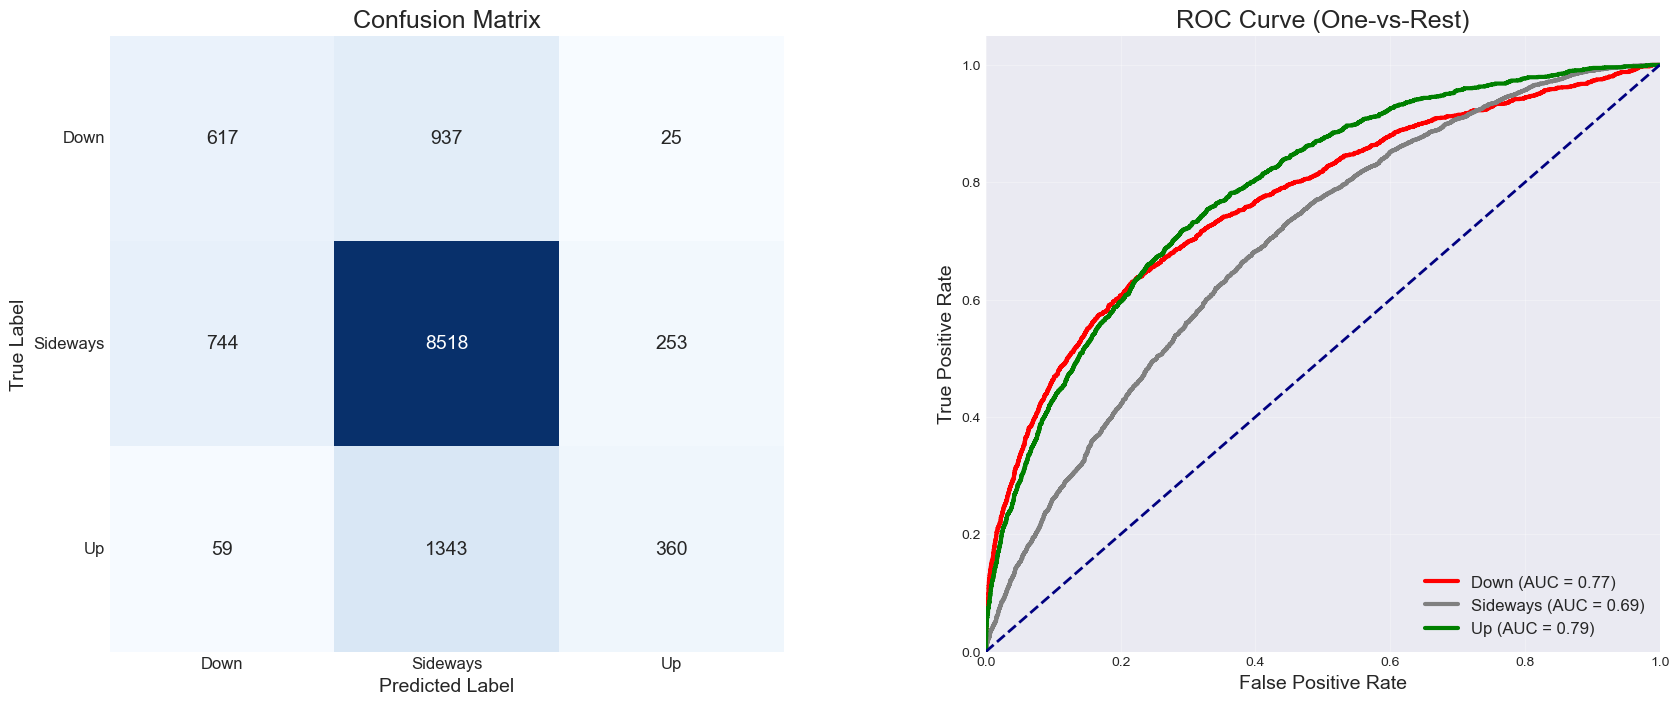

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# 1. Настройка имен классов
# 0 = Down, 1 = Sideways, 2 = Up
class_names_map = {0: 'Down', 1: 'Sideways', 2: 'Up'}

# Получаем уникальные классы из данных
unique_classes = sorted(list(set(y_test) | set(y_pred)))
target_names = [class_names_map.get(c, f"Class {c}") for c in unique_classes]

print(f"Classes detected: {unique_classes} -> {target_names}")

# 2. Текстовый отчет
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=target_names))

# 3. Графики
fig, axes = plt.subplots(1, 2, figsize=(20, 8)) # Оставим 2 графика: Matrix и ROC
plt.subplots_adjust(wspace=0.3)

# --- A. Confusion Matrix (Матрица ошибок) ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix', fontsize=18)
axes[0].set_xlabel('Predicted Label', fontsize=14)
axes[0].set_ylabel('True Label', fontsize=14)
axes[0].set_xticklabels(target_names, fontsize=12)
axes[0].set_yticklabels(target_names, fontsize=12, rotation=0)

# --- B. ROC Curve (Multi-class) ---
# Для мультикласса строим One-vs-Rest ROC
y_prob = final_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=unique_classes)

colors = ['red', 'gray', 'green'] # Red=Down, Gray=Sideways, Green=Up
for i, cls in enumerate(unique_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    label_name = class_names_map.get(cls, f"Class {cls}")

    # Выбираем цвет (если классов больше 3, будет циклично)
    color = colors[i] if i < len(colors) else None

    axes[1].plot(fpr, tpr, color=color, lw=3, label=f'{label_name} (AUC = {roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=14)
axes[1].set_ylabel('True Positive Rate', fontsize=14)
axes[1].set_title('ROC Curve (One-vs-Rest)', fontsize=18)
axes[1].legend(loc="lower right", fontsize=12)
axes[1].grid(alpha=0.3)

plt.show()


# Sanity Check

In [70]:
def create_hard_target(df):
    df = df.copy()
    # Если цена закрытия следующей свечи выше текущей -> 1 (UP), иначе 0 (DOWN)
    # shift(-1) берет цену из будущего для разметки
    df['target'] = (df['close'].shift(-1) > df['close']).astype(int)
    return df

# Используйте это вместо create_target_labels
df_labeled = create_hard_target(df)

In [86]:
def add_features(df):
    df = df.copy()

    # --- Volume Features ---
    df["volume_delta"] = df["ask_vol"] - df["bid_vol"]
    for window in [4, 12, 24, 96]:
        df[f"vol_delta_rolling_{window}"] = df["volume_delta"].rolling(window).sum()

    # --- Momentum Features ---
    df.ta.rsi(length=14, append=True)
    df.ta.macd(fast=12, slow=26, signal=9, append=True)
    df['ema_12'] = ta.ema(df['close'], length=12)
    df['ema_26'] = ta.ema(df['close'], length=26)
    df['trend_ema'] = np.where(df['ema_12'] > df['ema_26'], 1, -1)

    # --- Volatility Features ---
    df.ta.bbands(length=20, std=2, append=True)
    df['bb_width'] = (df['BBU_20_2.0'] - df['BBL_20_2.0']) / df['BBM_20_2.0']

    return df

# Apply Feature Engineering
df_full = add_features(df_labeled)

# Define Feature Columns (Exclude Target and Future Data)
feature_cols = [
    'volume_delta', 'vol_delta_rolling_4', 'vol_delta_rolling_12', 'vol_delta_rolling_24', 'vol_delta_rolling_96',
    'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'trend_ema',
    'bb_width', 'BBP_20_2.0'
]

# Shift features by 1 to prevent look-ahead bias (predicting NEXT bar using CURRENT features)
df_full[feature_cols] = df_full[feature_cols].shift(1)
df_full = df_full.dropna()

print(f"Features: {len(feature_cols)}")
print(feature_cols)


Features: 12
['volume_delta', 'vol_delta_rolling_4', 'vol_delta_rolling_12', 'vol_delta_rolling_24', 'vol_delta_rolling_96', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'trend_ema', 'bb_width', 'BBP_20_2.0']


In [101]:
# Prepare X and y
X = df_full[feature_cols]
y = df_full['target']

# Split Data (Time Series Split)
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_val = X.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]

X_test = X.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]

# Scale Features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define Hyperparameter Grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5]
}

# Initialize XGBoost
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    tree_method='hist', # Faster training
    max_depth=2,
    n_estimators=15
)

# Randomized Search (200 iterations)
print("Starting Grid Search (200 iterations)...")
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=TimeSeriesSplit(n_splits=3),
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print("Best Parameters:", random_search.best_params_)
best_model = random_search.best_estimator_


Starting Grid Search (200 iterations)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}


Classes in data: [0 1]

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.70      0.82      0.76      6714
          UP       0.33      0.20      0.25      2920

    accuracy                           0.63      9634
   macro avg       0.52      0.51      0.50      9634
weighted avg       0.59      0.63      0.60      9634



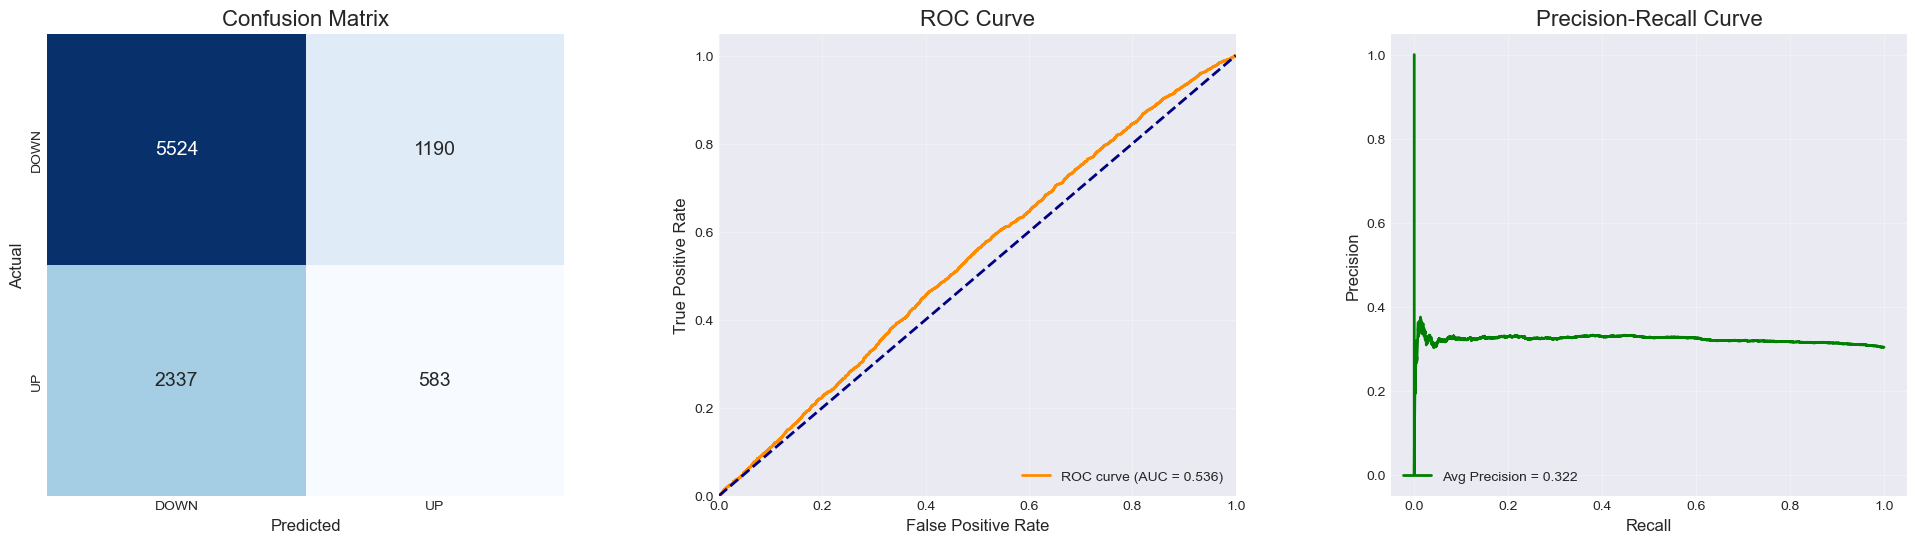

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ============================
# 1. Evaluate model on Test Set
# ============================

# Получаем предсказания
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1] # Вероятность класса 1 (UP)

# --- ИСПРАВЛЕНИЕ ОШИБКИ ---
# Принудительно превращаем в одномерные массивы (flatten)
y_test_flat = np.array(y_test).flatten().astype(int)
y_pred_flat = np.array(y_pred).flatten().astype(int)

# Теперь np.unique сработает без ошибок
unique_classes = np.unique(np.concatenate((y_test_flat, y_pred_flat)))
print(f"Classes in data: {unique_classes}")

# Имена классов (адаптируйте, если у вас 0=Down, 1=Up)
target_names = ['DOWN', 'UP']

print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_flat, target_names=target_names))

# ============================
# 2. Visualization
# ============================
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
plt.subplots_adjust(wspace=0.3)

# --- A. Confusion Matrix ---
cm = confusion_matrix(y_test_flat, y_pred_flat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix', fontsize=16)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xticklabels(target_names)
axes[0].set_yticklabels(target_names)

# --- B. ROC Curve (Binary) ---
fpr, tpr, _ = roc_curve(y_test_flat, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=16)
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

# --- C. Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test_flat, y_pred_proba)
avg_precision = average_precision_score(y_test_flat, y_pred_proba)

axes[2].plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {avg_precision:.3f}')
axes[2].set_xlabel('Recall', fontsize=12)
axes[2].set_ylabel('Precision', fontsize=12)
axes[2].set_title('Precision-Recall Curve', fontsize=16)
axes[2].legend(loc="lower left")
axes[2].grid(alpha=0.3)

plt.show()


# Event Horizon


In [124]:
def create_balanced_horizon_target_multiclass(df, horizon=12, quantile_top=0.7, quantile_bottom=0.3):
    """
    Создает 3 сбалансированных класса:
    2 (UP): Доходность выше quantile_top (например, топ 30% роста)
    0 (DOWN): Доходность ниже quantile_bottom (например, топ 30% падения)
    1 (SIDEWAYS): Всё, что посередине
    """
    df = df.copy()

    # Считаем будущую доходность
    df['future_return'] = df['close'].shift(-horizon) / df['close'] - 1

    # Вычисляем пороги
    # quantile_top=0.7 означает, что мы берем 30% самых высоких значений
    thresh_up = df['future_return'].quantile(quantile_top)

    # quantile_bottom=0.3 означает, что мы берем 30% самых низких значений
    thresh_down = df['future_return'].quantile(quantile_bottom)

    print(f"Threshold UP (> {thresh_up:.5f})")
    print(f"Threshold DOWN (< {thresh_down:.5f})")

    # Присваиваем классы
    conditions = [
        df['future_return'] > thresh_up,   # Класс 2: UP
        df['future_return'] < thresh_down  # Класс 0: DOWN
    ]
    choices = [2, 0]

    # np.select проверяет условия по очереди. Если ни одно не выполнено -> default=1
    df['target'] = np.select(conditions, choices, default=1)

    # Удаляем временную колонку
    df.drop(columns=['future_return'], inplace=True)

    return df

# Использование:
# Это создаст примерно: 30% UP, 30% DOWN, 40% SIDEWAYS
df_labeled = create_balanced_horizon_target_multiclass(df, horizon=10, quantile_top=0.8, quantile_bottom=0.2)

print(df_labeled['target'].value_counts(normalize=True))


Threshold UP (> 0.00467)
Threshold DOWN (< -0.00420)
target
1    0.600056
0    0.199972
2    0.199972
Name: proportion, dtype: float64


In [119]:
df_labeled

,time,total_vol,bid_vol,max_bid_vol,mod_bid_vol,avg_bid_vol,ask_vol,max_ask_vol,mod_ask_vol,avg_ask_vol,open,high,low,close,count,funding_rate,log_return,BBL_20_2.0,BBM_20_2.0,BBU_20_2.0,BBB_20_2.0,BBP_20_2.0,target
1,2024-01-01 00:15:00+00:00,2322.028,1229.331,39.160,0.003,0.145707,1092.697,30.074,0.003,0.129513,42532.4,42603.2,42449.1,42458.5,24805,0.000374,-0.001741,NaN,NaN,NaN,NaN,NaN,2
2,2024-01-01 00:30:00+00:00,1684.217,879.438,20.174,0.003,0.136326,804.779,14.077,0.003,0.124753,42458.4,42485.7,42386.2,42474.5,19365,0.000374,0.000377,NaN,NaN,NaN,NaN,NaN,1
3,2024-01-01 00:45:00+00:00,835.244,408.159,15.407,0.003,0.117625,427.085,18.973,0.003,0.123079,42474.5,42527.2,42449.1,42503.5,10240,0.000374,0.000683,NaN,NaN,NaN,NaN,NaN,1
4,2024-01-01 01:00:00+00:00,850.274,482.286,50.858,0.003,0.140077,367.988,16.992,0.003,0.106880,42503.5,42510.4,42462.0,42497.6,10626,0.000374,-0.000139,NaN,NaN,NaN,NaN,NaN,0
5,2024-01-01 01:15:00+00:00,826.420,368.753,16.814,0.003,0.102375,457.667,17.729,0.003,0.127059,42497.6,42554.9,42497.5,42524.8,11148,0.000374,0.000640,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64315,2025-10-31 22:45:00+00:00,260.413,167.139,7.300,0.002,0.044678,93.274,6.738,0.002,0.024933,109590.0,109597.1,109516.9,109543.0,10079,0.000002,-0.000429,109204.240143,109558.980,109913.719857,0.647578,0.477476,1
64316,2025-10-31 23:00:00+00:00,238.367,135.851,41.233,0.002,0.039944,102.516,7.243,0.002,0.030143,109543.0,109575.6,109500.2,109500.2,9243,0.000002,-0.000391,109217.663823,109564.685,109911.706177,0.633454,0.407088,1
64317,2025-10-31 23:15:00+00:00,127.820,48.470,3.786,0.002,0.016965,79.350,2.338,0.002,0.027774,109500.2,109587.9,109500.2,109578.7,7414,0.000002,0.000717,109279.235092,109583.560,109887.884908,0.555421,0.492015,1
64318,2025-10-31 23:30:00+00:00,286.848,126.314,7.655,0.002,0.028662,160.534,37.231,0.002,0.036427,109578.6,109622.9,109475.6,109620.1,13340,0.000002,0.000378,109280.377592,109578.310,109876.242408,0.543780,0.570133,1


In [125]:
def add_features(df):
    df = df.copy()

    # --- Volume Features ---
    df["volume_delta"] = df["ask_vol"] - df["bid_vol"]
    for window in [4, 12, 24, 96]:
        df[f"vol_delta_rolling_{window}"] = df["volume_delta"].rolling(window).sum()

    # --- Momentum Features ---
    df.ta.rsi(length=14, append=True)
    df.ta.macd(fast=12, slow=26, signal=9, append=True)
    df['ema_12'] = ta.ema(df['close'], length=12)
    df['ema_26'] = ta.ema(df['close'], length=26)
    df['trend_ema'] = np.where(df['ema_12'] > df['ema_26'], 1, -1)

    # --- Volatility Features ---
    df.ta.bbands(length=20, std=2, append=True)
    df['bb_width'] = (df['BBU_20_2.0'] - df['BBL_20_2.0']) / df['BBM_20_2.0']

    return df

# Apply Feature Engineering
df_full = add_features(df_labeled)

# Define Feature Columns (Exclude Target and Future Data)
feature_cols = [
    'volume_delta', 'vol_delta_rolling_4', 'vol_delta_rolling_12', 'vol_delta_rolling_24', 'vol_delta_rolling_96',
    'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'trend_ema',
    'bb_width', 'BBP_20_2.0'
]

# Shift features by 1 to prevent look-ahead bias (predicting NEXT bar using CURRENT features)
df_full[feature_cols] = df_full[feature_cols].shift(1)
df_full = df_full.dropna()

print(f"Features: {len(feature_cols)}")
print(feature_cols)

Features: 12
['volume_delta', 'vol_delta_rolling_4', 'vol_delta_rolling_12', 'vol_delta_rolling_24', 'vol_delta_rolling_96', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'trend_ema', 'bb_width', 'BBP_20_2.0']


In [126]:
 #Prepare X and y
X = df_full[feature_cols]
y = df_full['target']

# Split Data (Time Series Split)
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_val = X.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]

X_test = X.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]

# Scale Features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define Hyperparameter Grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5]
}

# # 1. Считаем баланс в тренировочной выборке
# n_neg = (y_train == 0).sum()
# n_pos = (y_train == 1).sum()
# ratio = n_neg / n_pos
# print(f"Ratio Negative/Positive: {ratio:.2f}")

# Initialize XGBoost
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    tree_method='hist', # Faster training
    max_depth=2,
    n_estimators=15
)

# # Initialize XGBoost
# xgb = XGBClassifier(
#     objective='binary:logistic',
#     eval_metric='logloss',
#     scale_pos_weight=ratio,
#     use_label_encoder=False,
#     random_state=42,
#     tree_method='hist', # Faster training
#     max_depth=2,
#     n_estimators=15
# )


# Randomized Search (200 iterations)
print("Starting Grid Search (200 iterations)...")
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_weighted',
    cv=TimeSeriesSplit(n_splits=3),
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print("Best Parameters:", random_search.best_params_)
best_model = random_search.best_estimator_


Starting Grid Search (200 iterations)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.6}


Classes in data: [0 1 2]

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.27      0.06      0.09      1505
    SIDEWAYS       0.71      0.95      0.81      6755
          UP       0.21      0.05      0.09      1374

    accuracy                           0.68      9634
   macro avg       0.40      0.35      0.33      9634
weighted avg       0.57      0.68      0.60      9634



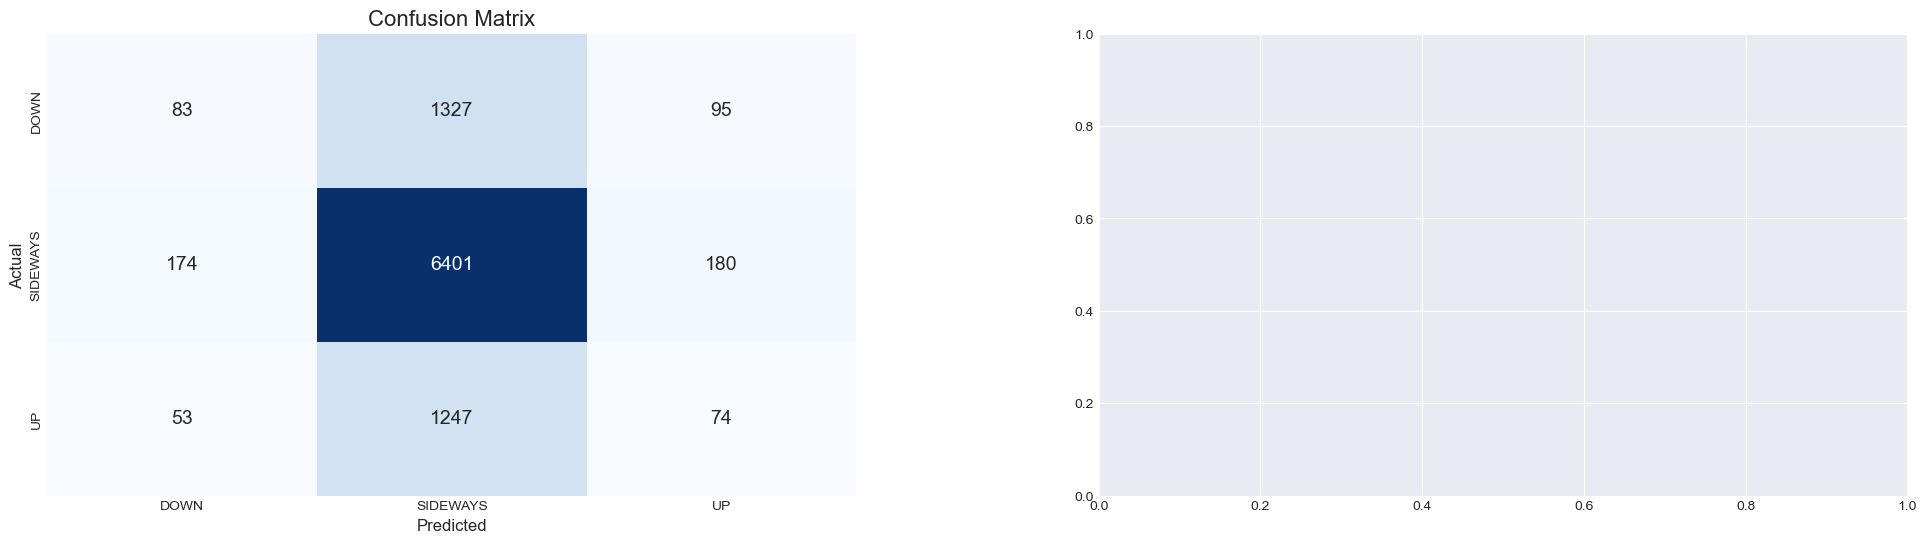

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ============================
# 1. Evaluate model on Test Set
# ============================

# Получаем предсказания
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1] # Вероятность класса 1 (UP)

# Принудительно превращаем в одномерные массивы (flatten)
y_test_flat = np.array(y_test).flatten().astype(int)
y_pred_flat = np.array(y_pred).flatten().astype(int)

# Теперь np.unique сработает без ошибок
unique_classes = np.unique(np.concatenate((y_test_flat, y_pred_flat)))
print(f"Classes in data: {unique_classes}")

# Имена классов (адаптируйте, если у вас 0=Down, 1=Up)
target_names = ['DOWN', 'SIDEWAYS','UP']

print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred_flat, target_names=target_names))

# ============================
# 2. Visualization
# ============================
fig, axes = plt.subplots(1, 2, figsize=(24, 6))
plt.subplots_adjust(wspace=0.3)

# --- A. Confusion Matrix ---
cm = confusion_matrix(y_test_flat, y_pred_flat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix', fontsize=16)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xticklabels(target_names)
axes[0].set_yticklabels(target_names)

# # --- B. ROC Curve (Binary) ---
# fpr, tpr, _ = roc_curve(y_test_flat, y_pred_proba)
# roc_auc = auc(fpr, tpr)
#
# axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
# axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# axes[1].set_xlim([0.0, 1.0])
# axes[1].set_ylim([0.0, 1.05])
# axes[1].set_xlabel('False Positive Rate', fontsize=12)
# axes[1].set_ylabel('True Positive Rate', fontsize=12)
# axes[1].set_title('ROC Curve', fontsize=16)
# axes[1].legend(loc="lower right")
# axes[1].grid(alpha=0.3)
#
# # --- C. Precision-Recall Curve ---
# precision, recall, _ = precision_recall_curve(y_test_flat, y_pred_proba)
# avg_precision = average_precision_score(y_test_flat, y_pred_proba)
#
# axes[2].plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {avg_precision:.3f}')
# axes[2].set_xlabel('Recall', fontsize=12)
# axes[2].set_ylabel('Precision', fontsize=12)
# axes[2].set_title('Precision-Recall Curve', fontsize=16)
# axes[2].legend(loc="lower left")
# axes[2].grid(alpha=0.3)

plt.show()